<a href="https://colab.research.google.com/github/MrJunVN/MrJunVN/blob/main/Task2Part1_Daniel_Q1.7_Q1.8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Student IDs: XXXXXXX, XXXXXXX, XXXXXX <br>
Student Names: xxxxxxx, xxxxxxx, xxxxxxx <br>
Group Number: 64 <br>
Workshop/Lab Session Time: Tuesday 5-7pm <br>

# **Part 1**

## Setting up Spark
In this section we:

*   Download a specific version of spark and set environment vairables so that this is the version that is used.
*   Install and use findspark
*   Import and create a SparkSession


In [1]:
# Install wget
!pip install wget

# Import wget so we can use from Python
import wget

##### This code is required for own spark version #####
# Update local version of the package catalog
#!apt-get update

# Install Java8
#!apt-get install openjdk-8-jdk-headless -qq > /dev/null

# Download spark 3.5.6
#!wget -q https://archive.apache.org/dist/spark/spark-3.5.6/spark-3.5.6-bin-hadoop3.tgz

# unzip it
#!tar xf spark-3.5.6-bin-hadoop3.tgz

#import os
#os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
#os.environ["SPARK_HOME"] = "/content/spark-3.5.6-bin-hadoop3"
###### OWN SPARK VERSION #####

# Install findspark
!pip install -q findspark

import findspark
findspark.init()

from pyspark.sql import SparkSession

# Create a SparkSession
spark = SparkSession.builder.appName("SIT742-A2-P1").getOrCreate()

# Get the SparkContext.
#sc = spark.SparkContext # MIGHT NOT NEED BUT HERE IF REQUIRED



  Preparing metadata (setup.py) ... done
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9655 sha256=f9b28c89522d875d488de79eaa373b8721e6179e88ac0d1bef7681e7ec4b0108
  Stored in directory: /root/.cache/pip/wheels/01/46/3b/e29ffbe4ebe614ff224bad40fc6a5773a67a163251585a13a9
Successfully built wget


In [2]:
# Print information about spark
spark

## Download and load data required for Part 1
This section creates a data directory, downloads the data files for part 1 from the SIT742 GitHub repositroy and extracts them into the data directory. Lastly the zip file is removed.

In [3]:
# Create data directory
!mkdir -p data

# Download the data for part 1 from the the GitHub repository
!wget -q https://github.com/tulip-lab/sit742/raw/develop/Jupyter/data/business_review_submission.zip

# Unzip the folder int othe data directory
!unzip business_review_submission.zip -d data

# Remove the zip file
!rm business_review_submission.zip


Archive:  business_review_submission.zip
  inflating: data/review.csv         
  inflating: data/meta-review-business.csv  


In [4]:
# Load the data into a DataFrame
data_file_path = "./data/review.csv"
sdf = spark.read.csv(data_file_path, header=True, inferSchema=True)

In [5]:
# Display schema of DataFrame
sdf.printSchema()

# Show the initial DataFrame
print("Initial DataFrame:")
sdf.show(10)

root
 |-- user_id: string (nullable = true)
 |-- name: string (nullable = true)
 |-- time: string (nullable = true)
 |-- rating: string (nullable = true)
 |-- text: string (nullable = true)
 |-- pics: string (nullable = true)
 |-- resp: string (nullable = true)
 |-- gmap_id: string (nullable = true)

Initial DataFrame:
+--------------------+--------------------+-------------+--------------------+--------------------+--------------------+----+--------------------+
|             user_id|                name|         time|              rating|                text|                pics|resp|             gmap_id|
+--------------------+--------------------+-------------+--------------------+--------------------+--------------------+----+--------------------+
|1.091298048426862...|          Nicki Gore|1566331951619|                   5|We always stay he...|                NULL|NULL|0x56b646ed2220b77...|
|1.132409264057589...|       Allen Ratliff|1504917982385|                   5|Great campgro

## Answer 1.1

In [6]:
""" 1.1.1
Repalce none/null in text column with "no review".
"""
from pyspark.sql.functions import col, count

# Count nulls for "text" column
text_null_counts = sdf.filter(col("text").isNull()).count()

# Display the counts
print(f'Null count in "text" column: {text_null_counts}')

# Replace none/NULL with "no review" in "text" column
sdf_filled = sdf.fillna("no review", subset=["text"])

# Count nulls for "text" column after replacement
null_count = sdf_filled.filter(col("text").isNull()).count()
print(f'Null count in "text" column after replacement: {null_count}')

#### Answers for report
# Why:
# Alternatives:
# 1. Using withColumn() and when().
# 2. Using Spark SQL.
# Optimal: The approach chosen is the most optimal. It avoids evaluating
# expressions.

Null count in "text" column: 249931
Null count in "text" column after replacement: 0


In [7]:
""" 1.1.2
Process the content in time column, and convert the strings from time to
yyyy-mm-dd format in the new column as newtime and show the first 5 rows.
"""

from pyspark.sql.functions import col, when, from_unixtime, regexp_extract, length, date_format

# Here we convert the time column into a string yyy-mm-dd format
# The time appeas to be a unix timetamp in milliseconds which will be 13 digits.
# I have assumed we are require to retun a string not a DateType
# For a DateType use this code instead:
# to_date(from_unixtime(col("time") / 1000))
#
sdf_with_date = sdf_filled.withColumn(
    "newtime", # new column name
    when(
        col("time").rlike("^[0-9]+$") &
        (length(col("time")) == 13),   # 13 digits for a unix timestamp in milliseconds
        date_format(from_unixtime(col("time") / 1000), "yyyy-MM-dd") # This creates a string column in yyyy-MM-dd format
        ).otherwise(None) # all others return Null
)

# Show the first five rows
sdf_with_date.show(5)

#### Answers for report
# Why:
# Alternatives:
# 1. Using expr() with inline SQL expressions in withColumn()
# 2. Using a user defined function (UDF) in withColumn()
# Optimal: Chosen approach is optimal as it uses native Spark functions and avoid any Python overhead.

+--------------------+--------------------+-------------+--------------------+--------------------+----+----+--------------------+----------+
|             user_id|                name|         time|              rating|                text|pics|resp|             gmap_id|   newtime|
+--------------------+--------------------+-------------+--------------------+--------------------+----+----+--------------------+----------+
|1.091298048426862...|          Nicki Gore|1566331951619|                   5|We always stay he...|NULL|NULL|0x56b646ed2220b77...|2019-08-20|
|1.132409264057589...|       Allen Ratliff|1504917982385|                   5|Great campground ...|NULL|NULL|0x56b646ed2220b77...|2017-09-09|
|1.130448378911412...|   Jonathan Tringali|1474765901185|                   4|We tent camped he...|NULL|NULL|                NULL|2016-09-25|
|There is a bath h...| 2 restrooms (sin...|       toilet| shower). The hot...| but they lack ve...|NULL|NULL|                NULL|      NULL|
|Wi-Fi


## Answer 1.2

In [8]:
""" 1.2.1
Using pyspark to calculate the number of reviews per each unique gmap_id and save as float
format in pyspark dataframe to show the top 5 rows.
"""

from pyspark.sql.types import FloatType

# Use groupby to get unique gmap_id, then count the reviews for each group, sort.
review_counts = sdf_with_date.groupby(["gmap_id"]).count()\
.withColumn("count", col("count").cast(FloatType())) \
.sort("count", ascending=False)

# Show the top 5 reviewers
review_counts.show(5)

#### Answers for report
# Why:
# Alternatives:
# 1. Using .agg() with count() on the groupby
# Optimal: Chosen method is more optimal as it doesn't have the overhead of an aggregation step.

+--------------------+-------+
|             gmap_id|  count|
+--------------------+-------+
|                NULL|46309.0|
|0x56c897b9ce6000d...| 2737.0|
|0x56c899d05892048...| 2555.0|
|0x56c897c63697ee3...| 2220.0|
|0x56c8965ee2fb87a...| 2202.0|
+--------------------+-------+
only showing top 5 rows



**should we remove the reviews that have a NULL gmap_id?**

In [9]:
# This is an aside. not require for assignment
# Number of uniquie gmap_id's
num_groups = sdf_with_date.select("gmap_id").distinct().count()
print(num_groups)

12468


In [10]:
""" 1.2.2
Transform the current pyspark dataframe to pandas dataframe (named as df)
and create the column reivew_time with the information of review time on hours
level. Print your df pandas dataframe with top 5 rows after creating the column
review_time.
"""

from pyspark.sql.functions import col
import pandas as pd

#REMOVE THIS
print(sdf_with_date.count())

# Use the newdate column to drop invalid time values
sdf_cleaned = sdf_with_date.na.drop(subset=["newtime"])

#REMOVE THIS
print(sdf_cleaned.count())

# Convert the current pyspark dataframe to pandas
df = sdf_cleaned.toPandas()
df.memory_usage(deep=True).sum() / (1024 ** 2)  # in MB

# Create a DateTime coumn as it will be useful later
# time column is unixtime in milliseconds
df["date_time"] = pd.to_datetime(df["time"].astype(int), unit="ms")

# dt.hour sets the time in hours
df["review_time"] = df["date_time"].dt.hour

# Show the top 5 rows of the pandas dataframe
df.head(5)

#### Answers for report
# Why:
# Alternatives:
# 1. datetime.ftomtimestamp() inside an .apply()
# Optimal: Chosen method is optimal as it works on columns not rows like .apply().

552624
521515


,user_id,name,time,rating,text,pics,resp,gmap_id,newtime,date_time,review_time
0,1.091298048426862e+20,Nicki Gore,1566331951619,5,We always stay here when in Valdez for silver ...,None,None,0x56b646ed2220b77f:0xd8975e316de80952,2019-08-20,2019-08-20 20:12:31.619,20
1,1.1324092640575896e+20,Allen Ratliff,1504917982385,5,Great campground for the price. Nice hot unlim...,None,None,0x56b646ed2220b77f:0xd8975e316de80952,2017-09-09,2017-09-09 00:46:22.385,0
2,1.1304483789114126e+20,Jonathan Tringali,1474765901185,4,We tent camped here for 2 nights while explori...,None,None,None,2016-09-25,2016-09-25 01:11:41.185,1
3,1.1032915514759202e+20,S Blad,1472858535682,4,"This place is just a few miles outside Valdez,...",None,None,0x56b646ed2220b77f:0xd8975e316de80952,2016-09-02,2016-09-02 23:22:15.682,23
4,1.08989634908602e+20,Daniel Formoso,1529649811341,5,Probably the nicest and cleanest campground we...,None,None,0x56b646ed2220b77f:0xd8975e316de80952,2018-06-22,2018-06-22 06:43:31.341,6


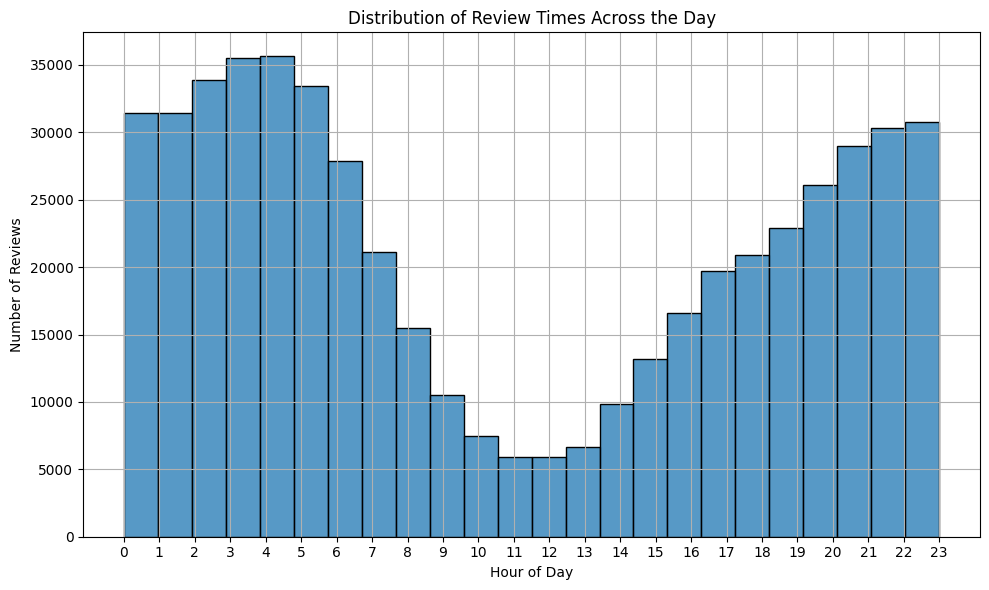

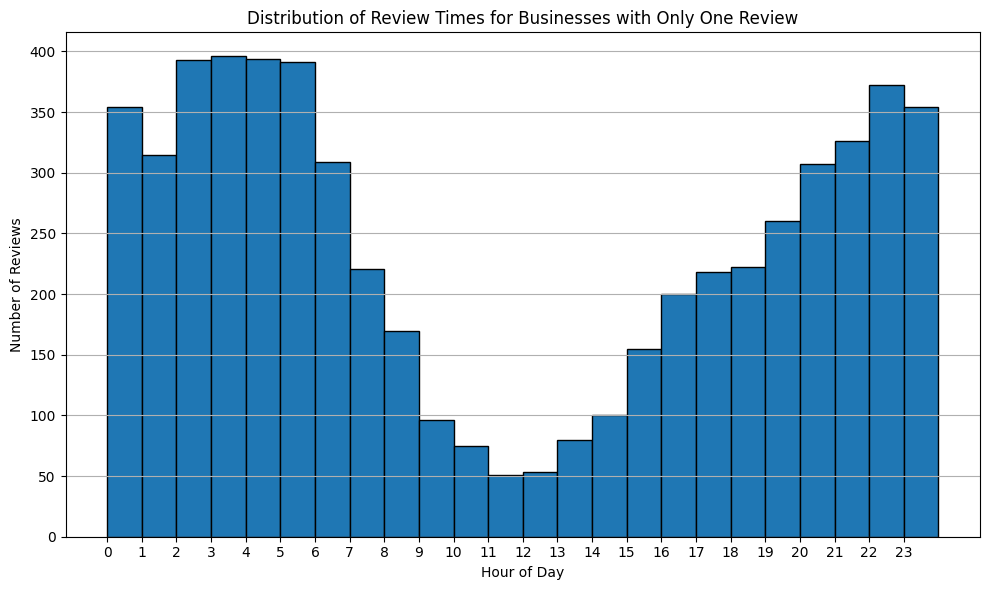

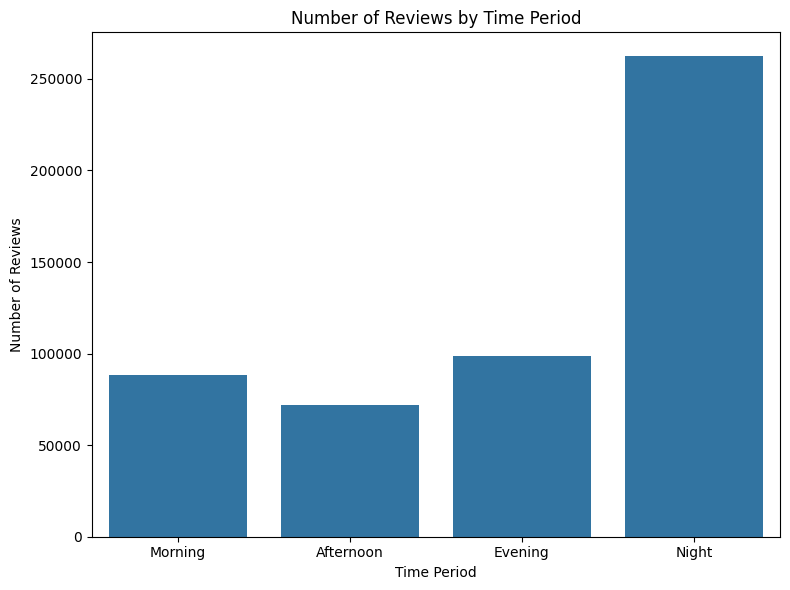

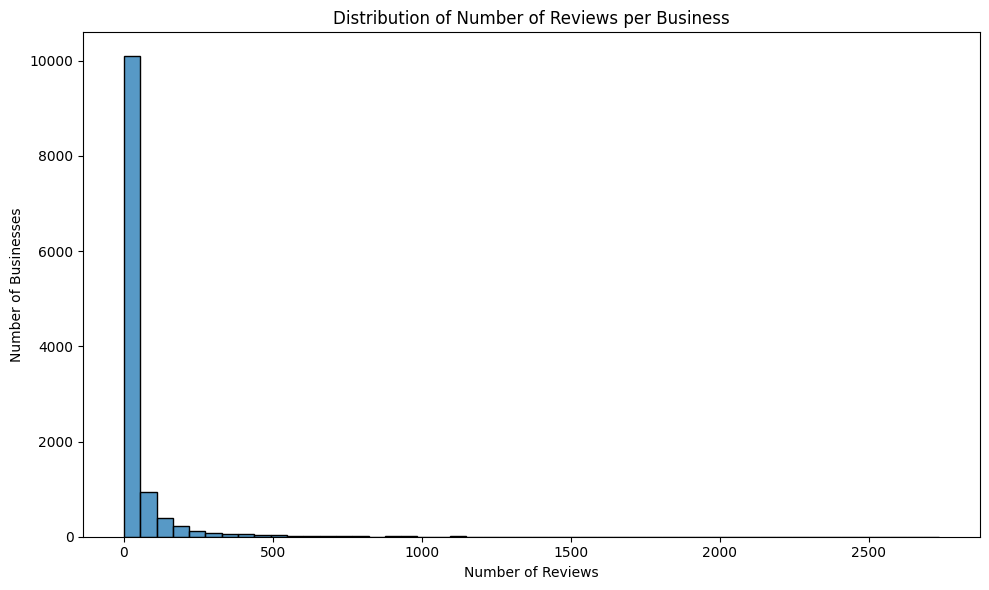

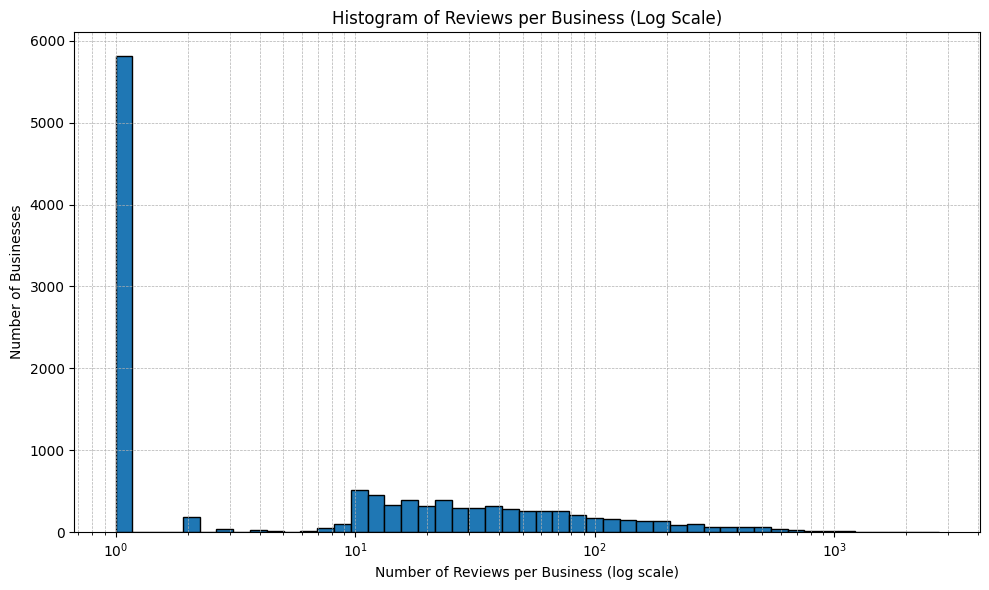

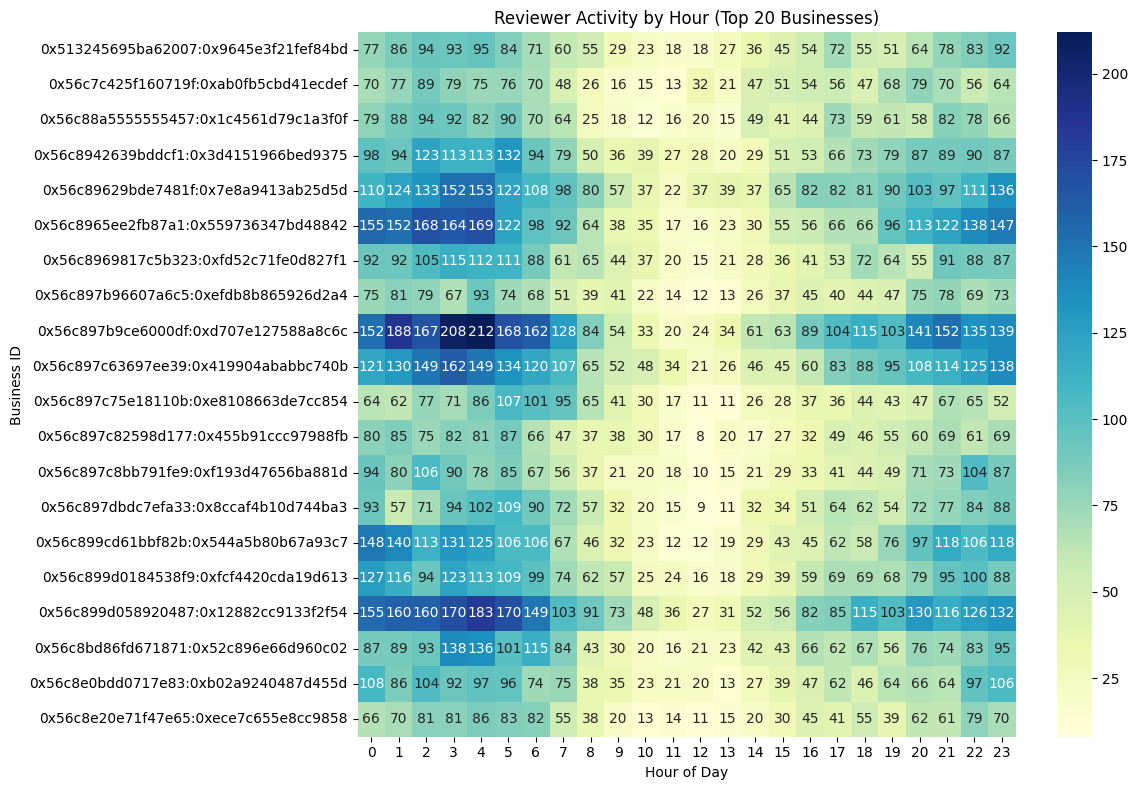

In [11]:
""" 1.2.3
Using matplotlib or seaborn to draw some (two or more if possible) visualizations on the
relationship between gmap_id and reivew_time. You could explore for example, what is the
time people usually review? How many business is reviewed in the morning time etc. Please
also discuss the insights you are finding with your visualizations in the markdown cell. Please
also include your findings and visualizations in the report.


Plots:
1. Distribution of Review Times across the day
   - What time do people usually leave reviews?
2. Number of reviews by time period Morning Hours (6am–12pm), Afternoon Hours (12pm–6pm), Evening Hours (6pm–9pm), Night (9pm-6am)
   - How active are reviewers during different parts of the day?
3. Histogram of Number of Reviews per business:
4. Reviewer Activity by Hour heatmap (Top 20 Businesses)
   - Do most reviewed businesses recieve revews at a particular time?
   - Are there consistent patterns in their activity?
"""
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define time periods
def get_time_period(hour):
  """
  """
  if 6 <= hour < 12:
    return "Morning"
  elif 12 <= hour < 18:
    return "Afternoon"
  elif 18 <= hour < 22:
    return "Evening"
  else:
    return "Night"

# Create timeperiod from review_time
df["time_period"] = df["review_time"].apply(get_time_period)

# Get a count of reviews per gmap_id
review_counts = df["gmap_id"].value_counts()

# Plot 1: Distribution of review times across the day
# What time do people usually leave reviews?
plt.figure(figsize=(10, 6))
sns.histplot(df["review_time"], bins=24, kde=False)
plt.title("Distribution of Review Times Across the Day")
plt.xlabel("Hour of Day")
plt.ylabel('Number of Reviews')
plt.xticks(range(0, 24))
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot 1b: Distribution of review times for businesses with only one review
# Filter to businesses with exactly one review
single_reviews = review_counts[review_counts == 1].index
df_single = df[df["gmap_id"].isin(single_reviews)]

# Plot histogram of review hours
plt.figure(figsize=(10, 6))
plt.hist(df_single["review_time"], bins=24, range=(0, 24), edgecolor="black")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Reviews")
plt.title("Distribution of Review Times for Businesses with Only One Review")
plt.xticks(range(0, 24))
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# Plot 2: Number of Reviews by Time Period
plt.figure(figsize=(8, 6))
sns.countplot(x='time_period', data=df, order=['Morning', 'Afternoon', 'Evening', 'Night'])
plt.title('Number of Reviews by Time Period')
plt.xlabel('Time Period')
plt.ylabel('Number of Reviews')
plt.tight_layout()
plt.show()

# Plot 3: Histogram of number of reviews per business
plt.figure(figsize=(10, 6))
sns.histplot(review_counts, bins=50, kde=False)
plt.title("Distribution of Number of Reviews per Business")
plt.xlabel("Number of Reviews")
plt.ylabel("Number of Businesses")
plt.tight_layout()
plt.show()

# Create histogram with log scale on x-axis
plt.figure(figsize=(10, 6))
plt.hist(review_counts, bins=np.logspace(np.log10(1), np.log10(max(review_counts)), 50), edgecolor="black")
plt.xscale("log")
plt.xlabel("Number of Reviews per Business (log scale)")
plt.ylabel("Number of Businesses")
plt.title("Histogram of Reviews per Business (Log Scale)")
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.tight_layout()
plt.show()

# Create a boxplot
#plt.figure(figsize=(10, 6))
#plt.boxplot(review_counts, vert=False)
#plt.title("Distribution of Number of Reviews per Business")
#plt.xlabel("Number of Reviews")
#plt.grid(True)
#plt.tight_layout()
#plt.show()

# Create a violin plot
#plt.figure(figsize=(10, 6))
#sns.violinplot(data=review_counts, inner="box", orient="h", color="skyblue")
#plt.title("Distribution of Number of Reviews per Business")
#plt.xlabel("Number of Reviews")
#plt.tight_layout()
#plt.show()


# Plot 4: Heatmap of reviewer activity by hour (top 20 businesses)
top_reviewers = review_counts.head(20).index
top_df = df[df["gmap_id"].isin(top_reviewers)]

# Create a pivot table: rows = businesses, columns = hours, values = number of reviews
activity_matrix = top_df.pivot_table(index="gmap_id", columns="review_time", aggfunc="size", fill_value=0)

plt.figure(figsize=(12, 8))
sns.heatmap(activity_matrix, cmap="YlGnBu", annot=True, fmt="d")
plt.title("Reviewer Activity by Hour (Top 20 Businesses)")
plt.xlabel("Hour of Day")
plt.ylabel("Business ID")
plt.tight_layout()
plt.show()

## Answer 1.3

Workday with the highest average number of reviews: Sunday


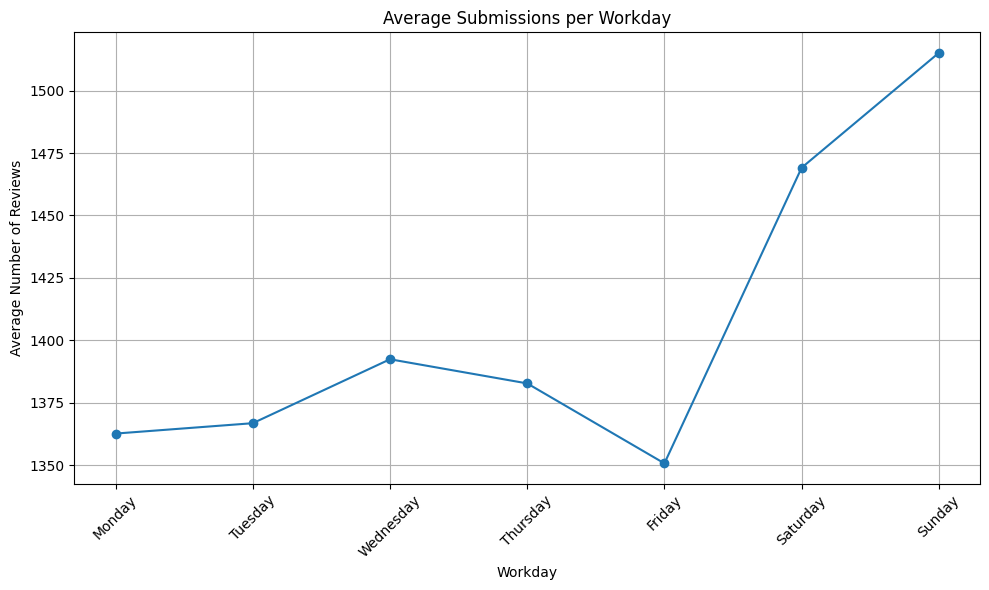

In [12]:
""" 1.3.1 Determine which workday (day of the week), generates the most reviews (plotting the results
in a line chart with workday on averaged submissions).
"""
import matplotlib.pyplot as plt
# Use the time column to get a DateTime object
# extract the day of the week from the DateTime object
df["workday"] = df["date_time"].dt.strftime("%A")

# Also need the week number to average the submissions
df["week"] = df["date_time"].dt.isocalendar().week

# Calculate the number of reviews for each day in each week
weekly_counts = df.groupby(["week", "workday"]).size().reset_index(name="review_counts")

# Calculate average reviews per weekday across all weeks
# Reindex for plotting
average_reviews = weekly_counts.groupby("workday")['review_counts'].mean().reindex([
    "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"
])

# Identify the weekday with the highest average reviews
busiest_workday = average_reviews.idxmax()
print(f"Workday with the highest average number of reviews: {busiest_workday}")

# Plotting the results in a line chart
plt.figure(figsize=(10, 6))
plt.plot(average_reviews.index, average_reviews.values, marker='o', linestyle='-')
plt.title("Average Submissions per Workday")
plt.xlabel("Workday")
plt.ylabel("Average Number of Reviews")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


The number of business that recived an average rating of 5.0 on Sunday's is 1120.


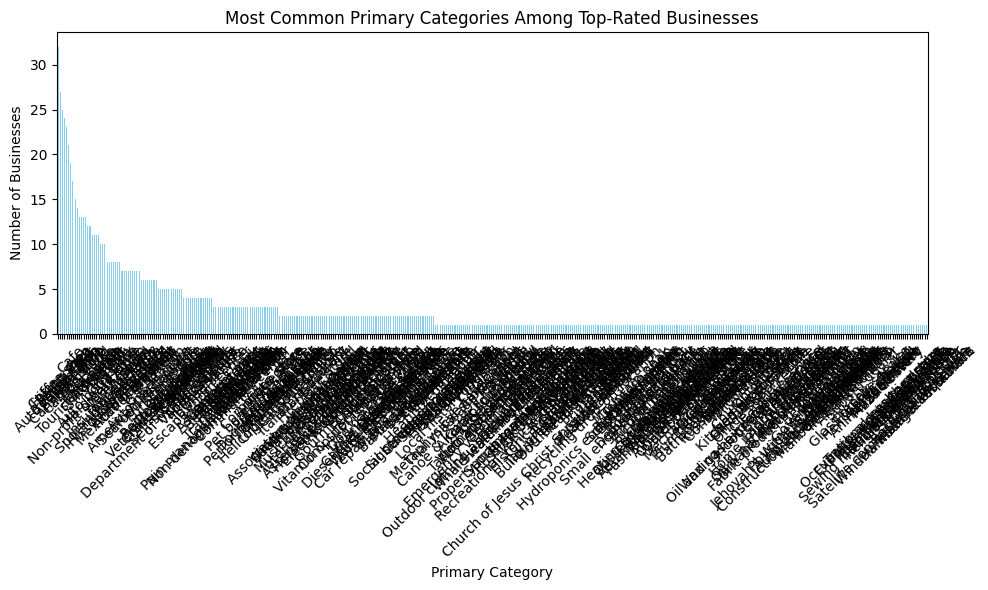

In [14]:
""" 1.3.2 Identify the names of business (column name from data meta-business) that has the highest
averaged ratings on ‘that workday’ (you need to find out from 1.3.1), and find out which
category those businesses are from?
"""
from collections import Counter
import ast

# Load meta-review-business data
meta_file_path = "./data/meta-review-business.csv"
meta_business_df = pd.read_csv(meta_file_path)
meta_business_df = meta_business_df.rename(columns={"name": "business_name", "category": "business_category"})

# Select only the relevant columns from meta-review-business
meta_subset_df = meta_business_df[["gmap_id", "business_name", "business_category"]]

# Filter reviews for the busiest weekday
reviews_on_busiest_day = df[df["workday"] == busiest_workday]

# Join with meta-business to get business names and categories
merged_df = pd.merge(reviews_on_busiest_day, meta_subset_df, on="gmap_id", how="left")

# Need to ensure rating values are floats
merged_df["rating"] = pd.to_numeric(merged_df["rating"], errors='coerce')

# Calculate average rating per business
avg_ratings = merged_df.groupby("business_name")["rating"].mean()

# Find business(es) with highest average rating
max_avg_rating = avg_ratings.max()
top_businesses = avg_ratings[avg_ratings == max_avg_rating].index.tolist()

print(f"The number of business that recived an average rating of {max_avg_rating} on {busiest_workday}'s is {len(top_businesses)}.")

# Filter merged_df to include only top-rated businesses
filtered_df = merged_df[merged_df["business_name"].isin(top_businesses)]

# Select business name and category
top_bus_cat = filtered_df[["business_name", "business_category"]]

# Drop duplicates
top_bus_cat = top_bus_cat.drop_duplicates("business_name").reset_index(drop=True)

# Categories are stories as strings, convert them to a list
top_bus_cat["business_category"] = top_bus_cat["business_category"].apply(ast.literal_eval)

# Extract only the first category from each list
top_bus_cat["primary_category"] = top_bus_cat["business_category"].apply(lambda x: x[0] if isinstance(x, list) and x else None)

# Count the most common primary categories
category_counts = top_bus_cat["primary_category"].value_counts()

# Plot the results
plt.figure(figsize=(10, 6))
category_counts.plot(kind="bar", color="skyblue")
plt.title("Most Common Primary Categories Among Top-Rated Businesses")
plt.xlabel("Primary Category")
plt.ylabel("Number of Businesses")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### WIP: NEED TO FIGURE OUT HOW TO VISUALISE THE DATA BETTER. MAYBE A WORD CLOUD OR TREEMAP?

## Answer 1.4

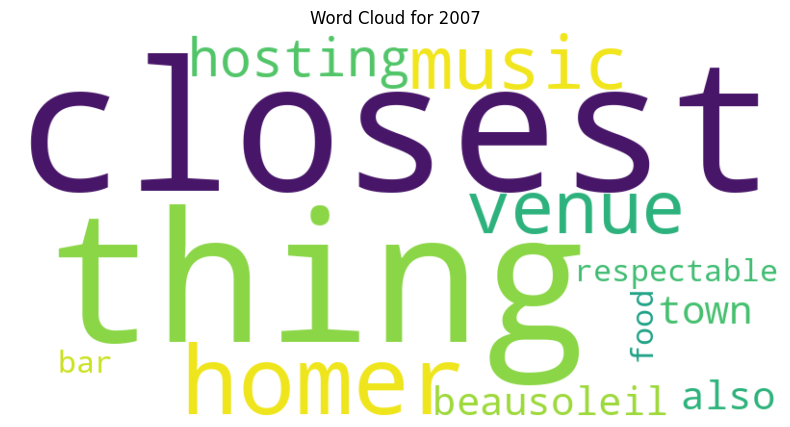

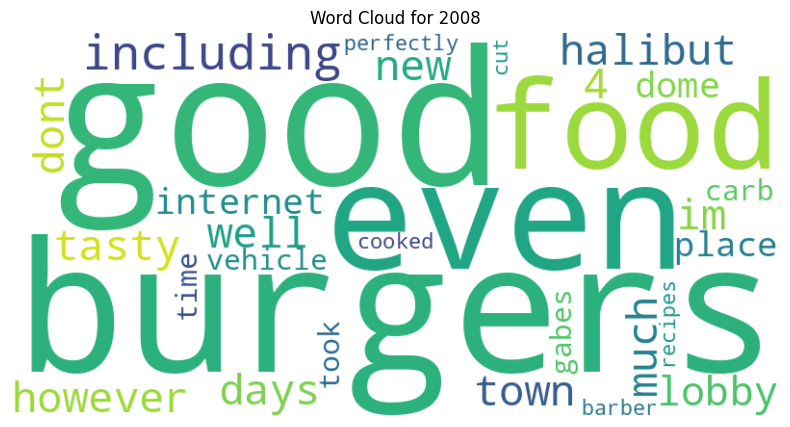

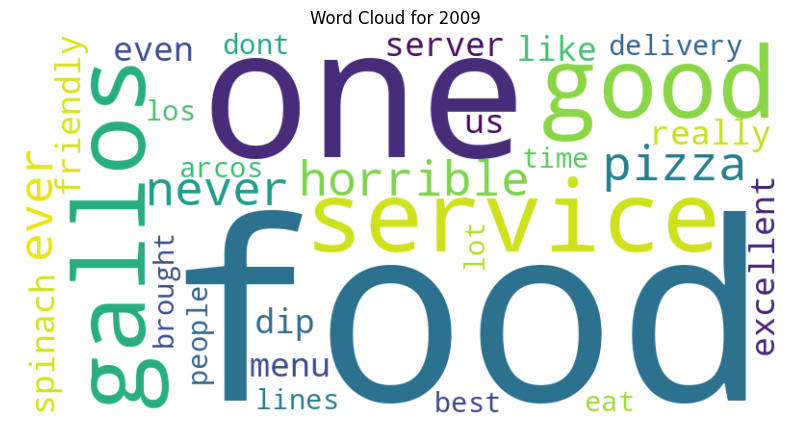

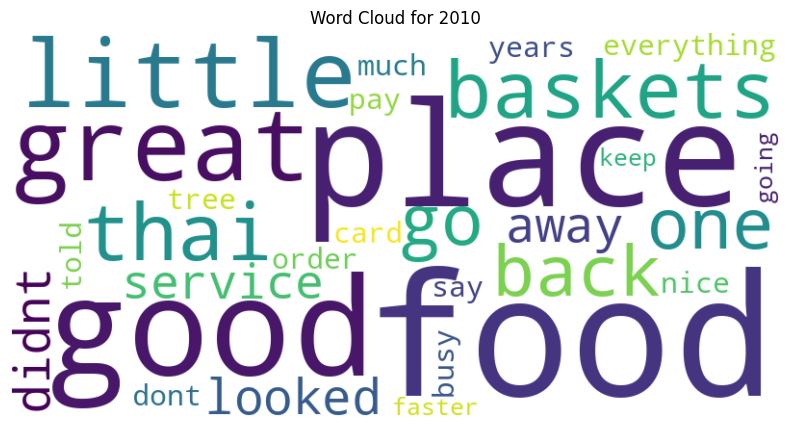

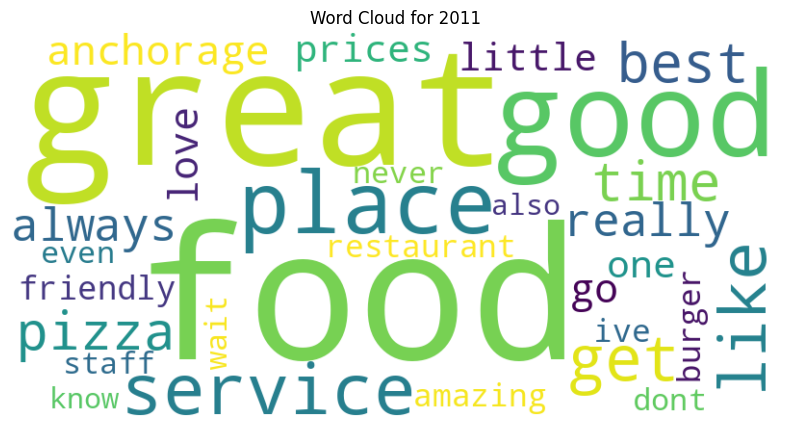

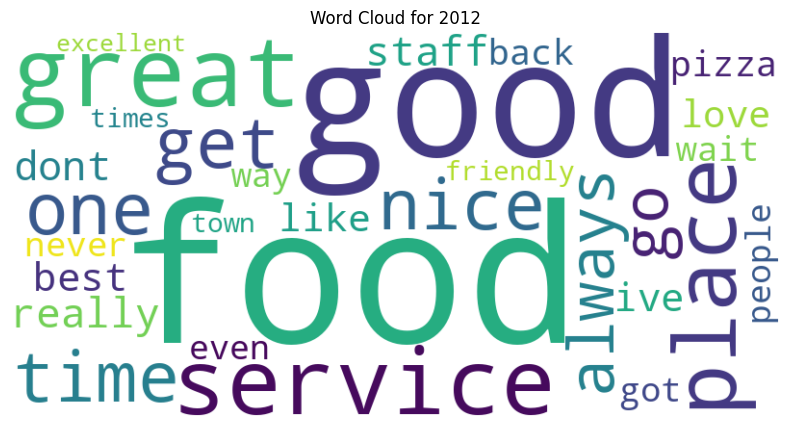

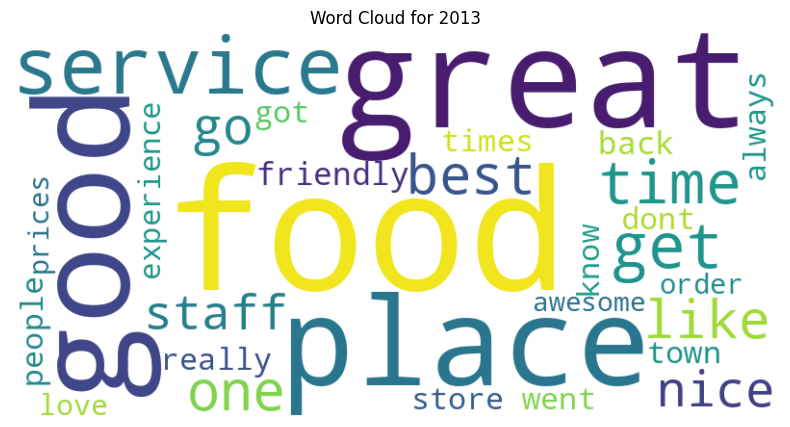

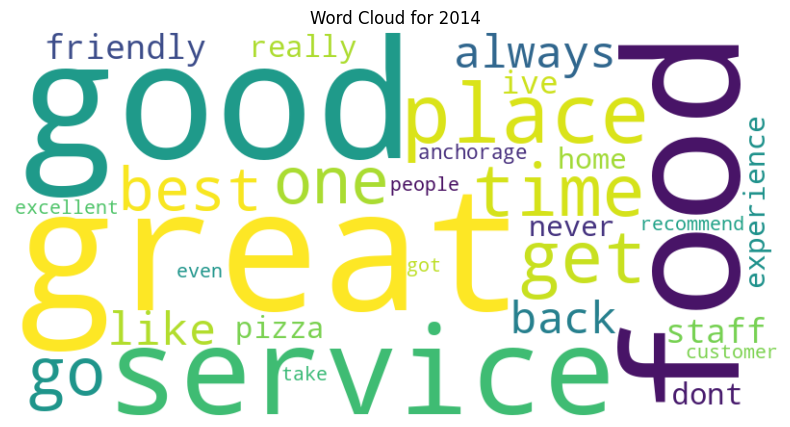

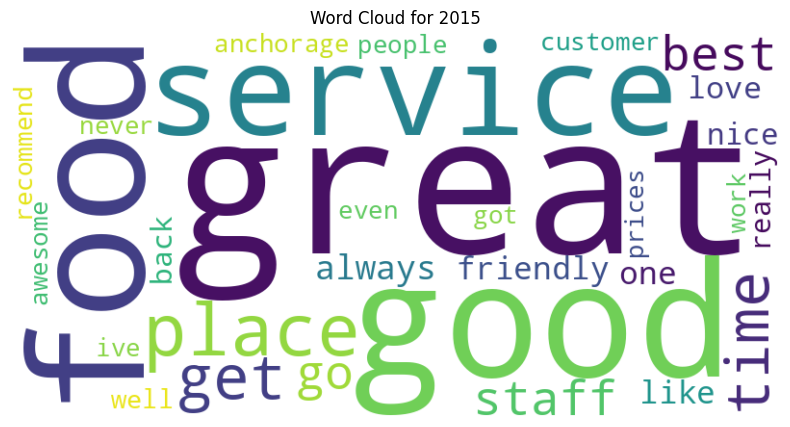

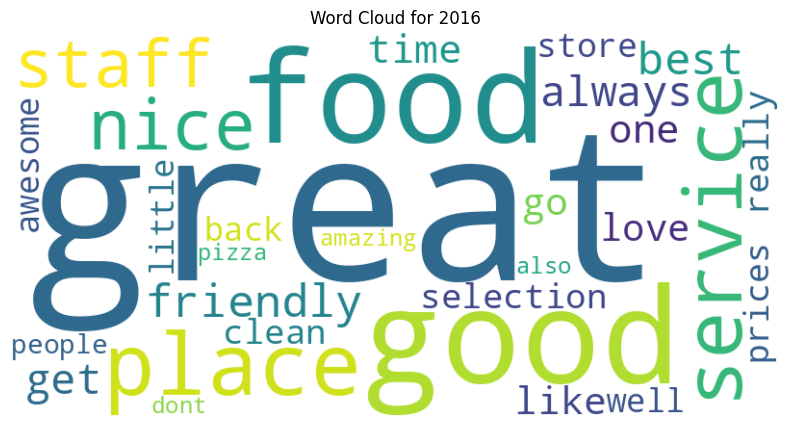

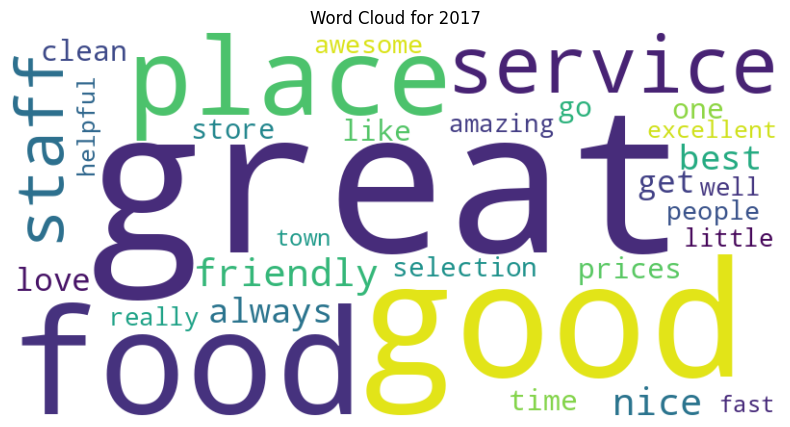

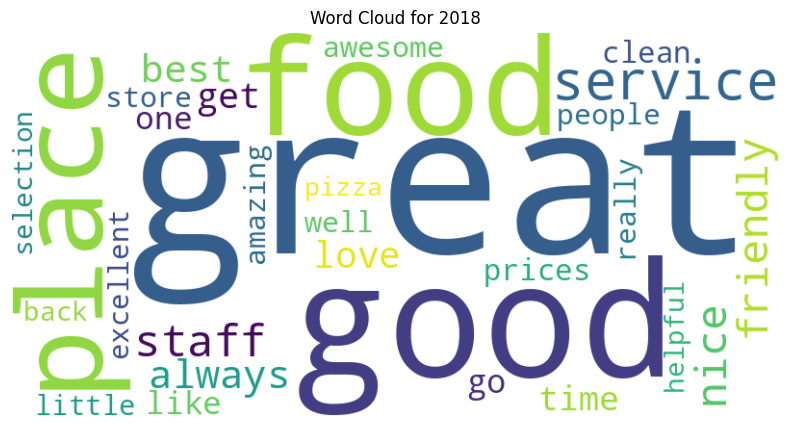

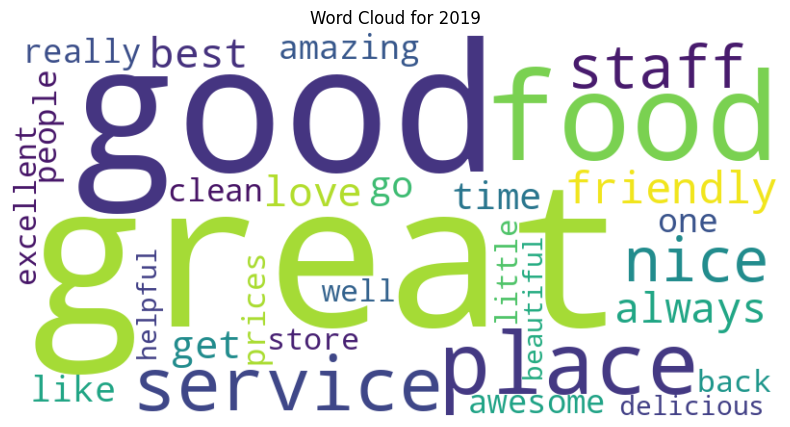

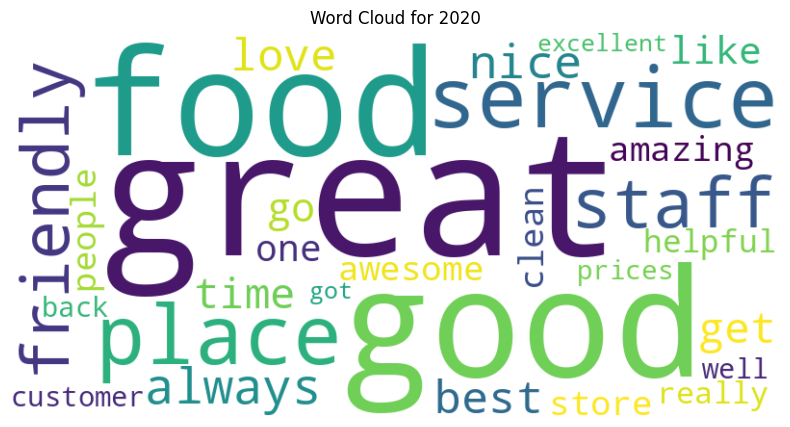

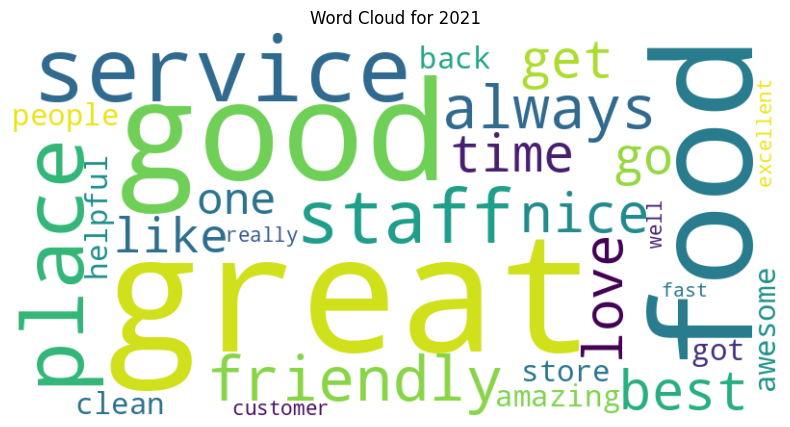

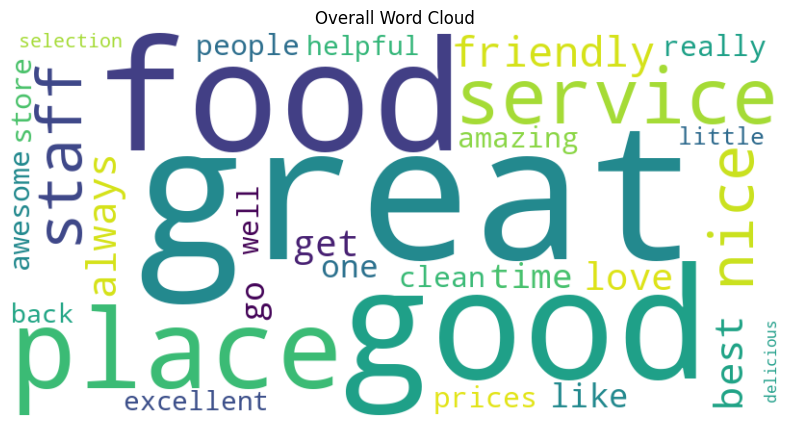

In [15]:
""" 1.4 Find top 30 common words in reviews. Generate word clouds by review year.

Decided to use pySpark for this question as we are ptentially working with large
data.
"""

from pyspark.sql.functions import explode, split, lower, col, regexp_replace, year, to_date, collect_list, flatten
from pyspark.ml.feature import StopWordsRemover
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Create new dataframe with only the columns we need.
words_sdf = sdf_cleaned.select("newTime", "text")

# Create "year" column from "newTime" to date and extract year.
words_sdf = words_sdf.withColumn("year",
                               year(to_date(col("newTime"), "yyyy-MM-dd")))

# For entries in the text column, remove punctuation and special charaters,
# keeping only letter, numbers and spaces.
# Convert the remaining text to lower case and split into a list of words at spaces
# Rename the column word_list
words_sdf = words_sdf.withColumn("words_list",
        split(
            lower(
                regexp_replace(col("text"), "[^a-zA-Z0-9\\s]", "")
            ), "\\s+"
        )
)

# Remove stop words (“the”, “is”, “and”) words using StopWordsRemover
# Get default stop words
default_stopwords = StopWordsRemover().getStopWords()

# In 1.1.1 we replaced NULL entries with "no review".
custom_stopwords = default_stopwords + ["no", "review"]

# Input column is words_list output column filtered
remover = StopWordsRemover(inputCol="words_list",
                           outputCol="filtered_words").setStopWords(custom_stopwords)

# Do the removal
words_sdf = remover.transform(words_sdf)

# Group by year and collect all words into one list for each year flattening the list for each year
grouped_yrs = words_sdf.groupBy("year").agg(flatten(collect_list("filtered_words")).alias("all_words"))

# Convert to Pandas for word cloud generation
grouped_yrs_pd = grouped_yrs.toPandas()

# Sort by year in ascending order
grouped_yrs_pd_sorted = grouped_yrs_pd.sort_values(by="year")

# Count words and generate word clouds
year_word_counts = {}
for _, row in grouped_yrs_pd_sorted.iterrows():
    year = row["year"]
    words = row["all_words"]
    word_freq = Counter(words).most_common(30)
    year_word_counts[year] = dict(word_freq)

    # Generate word cloud for each year
    wc = WordCloud(width=800, height=400, background_color="white").generate_from_frequencies(year_word_counts[year])
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Word Cloud for {int(year)}")
    plt.show()

# Overall word cloud
overall_counter = Counter()
for freq_dict in year_word_counts.values():
    overall_counter.update(freq_dict)

overall_top_30 = dict(overall_counter.most_common(30))

# Plot
wc = WordCloud(width=800, height=400, background_color="white").generate_from_frequencies(overall_top_30)
plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Overall Word Cloud")
plt.show()


## Answer 1.5

In [16]:
""" 1.5 A
Determine the number of unique reviewers of business and its categories to identify
which business / category has attracted the most reviewers (find out the highest
 distinct count of reviewers on business / category level).
"""

#### NOTE THIS CELL USES THE merged_df FROM Q1.3 #####

# Number of unique reviewers
unique_user_count = merged_df['user_id'].nunique()

print(f"Number of unique reviewers: {unique_user_count}")

# Businesses with the highest number of unique reviews
unique_reviewers_per_business = merged_df.groupby("business_name")["user_id"].nunique()

# Sort businesses from highest to lowest and print top 3
top_3_businesses = unique_reviewers_per_business.sort_values(ascending=False).head(3)
print("\nTop 3 businesses with the highest number of unique reviewers:")
for business, count in top_3_businesses.items():
    print(f"{business}: {count}")

# Businesses category with the highest number of unique reviews
unique_reviewers_per_category = merged_df.groupby("business_category")['user_id'].nunique()

# Sort businesses from highest to lowest and print top 3
top_3_categories = unique_reviewers_per_category.sort_values(ascending=False).head(3)
print("\nTop 3 categories with the highest number of unique reviewers:")
for category, count in top_3_categories.items():
    print(f"{category}: {count}")


Number of unique reviewers: 14355

Top 3 businesses with the highest number of unique reviewers:
McDonald's: 1373
Walmart Supercenter: 1262
Carrs: 840

Top 3 categories with the highest number of unique reviewers:
['Shopping mall']: 1399
['Fast food restaurant', 'Breakfast restaurant', 'Coffee shop', 'Hamburger restaurant', 'Restaurant', 'Sandwich shop']: 1373
['Department store', 'Clothing store', 'Craft store', 'Discount store', 'Electronics store', 'Grocery store', 'Home goods store', 'Sporting goods store', 'Supermarket', 'Toy store']: 1262


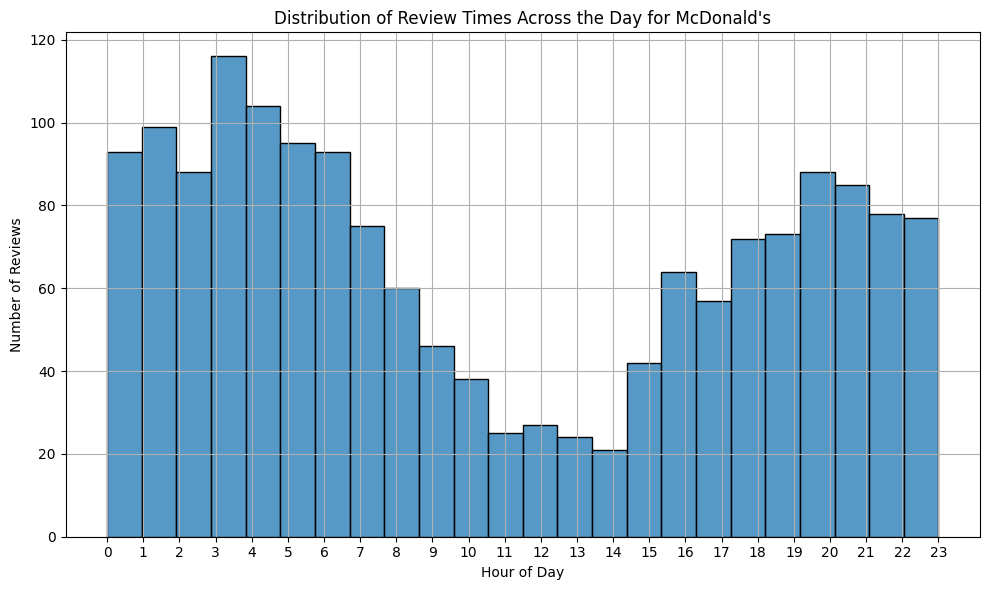

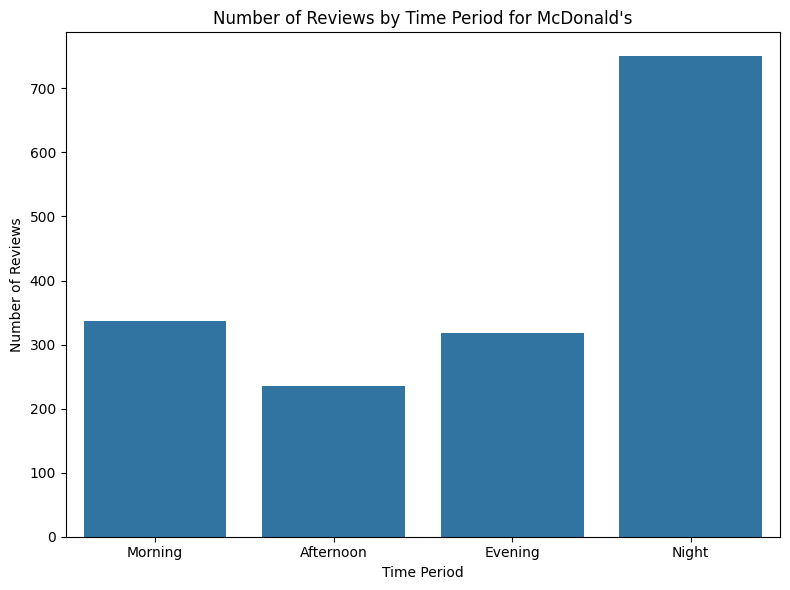

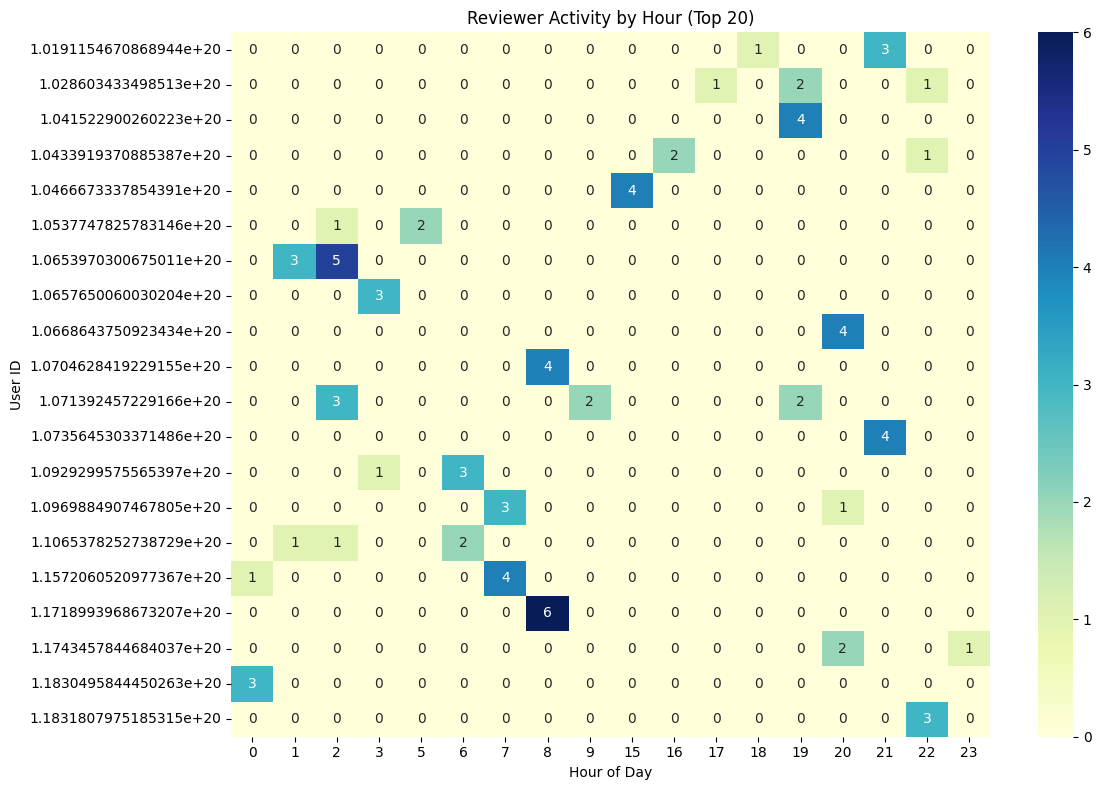

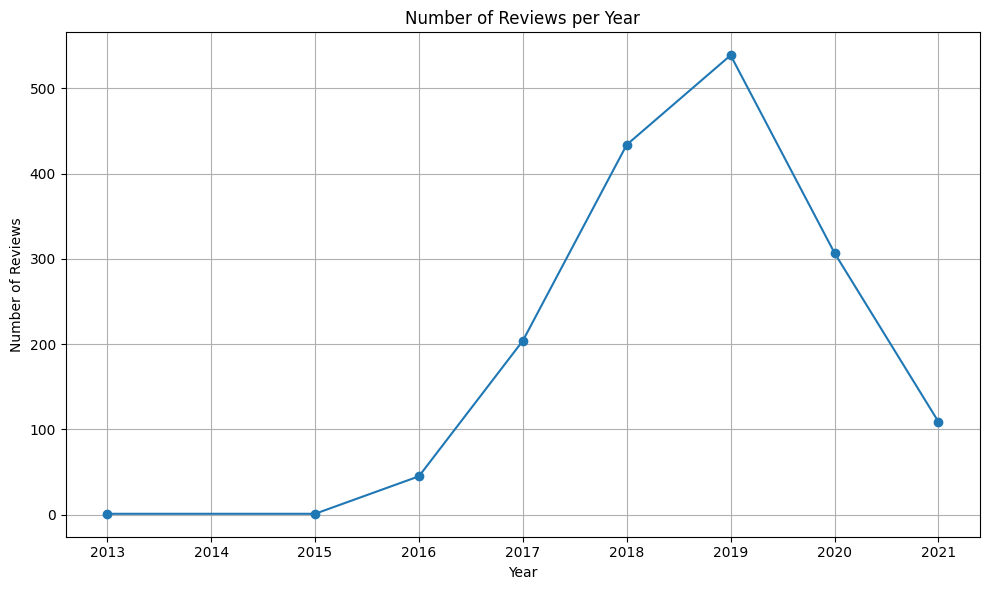

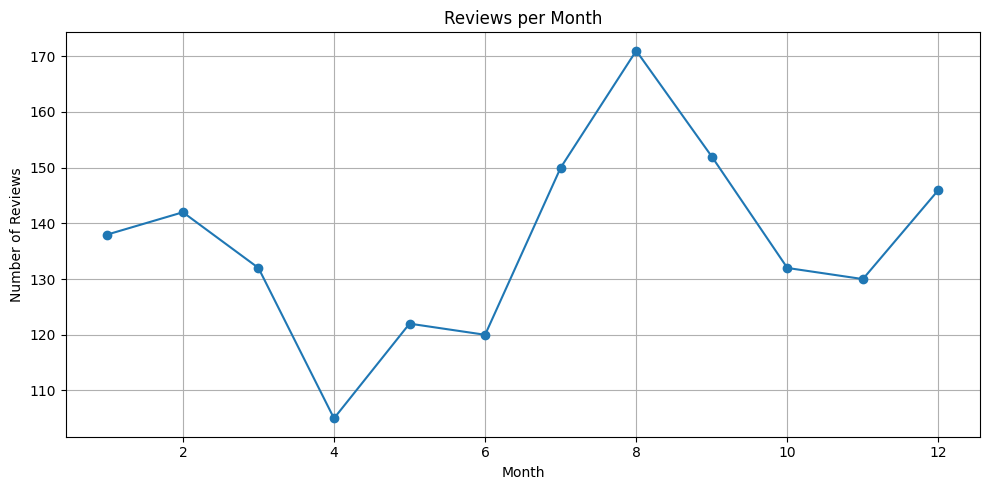

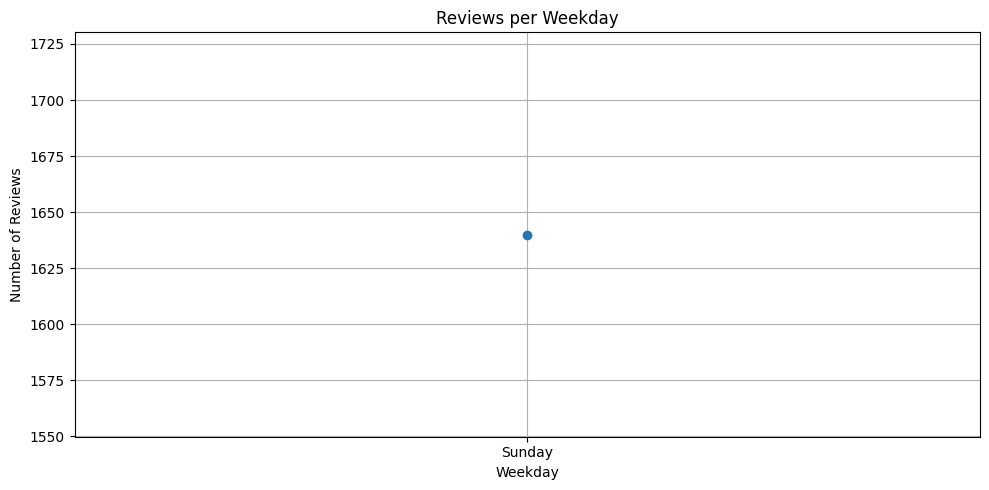

In [17]:
""" 1.5 B
Also, analyze the temporal patterns of when reviewers submitted their reviews (you could leverage the workday,
year, month, or hours to conduct the analysis) and share your findings and insights in the markdown
cell.
"""

top_business_name = top_3_businesses.index[0]

# Filter reviews for the top Business
top_business_reviews = merged_df[merged_df["business_name"] == top_business_name].copy()

# Get a count of reviews per used_if
top_business_reviewer_counts = top_business_reviews["user_id"].value_counts()

# Plot 1: Distribution of review times across the day
# What time do people usually leave reviews?
plt.figure(figsize=(10, 6))
sns.histplot(top_business_reviews["review_time"], bins=24, kde=False)
plt.title(f"Distribution of Review Times Across the Day for {top_business_name}")
plt.xlabel("Hour of Day")
plt.ylabel('Number of Reviews')
plt.xticks(range(0, 24))
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot 2: Number of Reviews by Time Period
plt.figure(figsize=(8, 6))
sns.countplot(x="time_period", data=top_business_reviews, order=["Morning", "Afternoon", "Evening", "Night"])
plt.title(f"Number of Reviews by Time Period for {top_business_name}")
plt.xlabel("Time Period")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

# Plot 3: Heatmap of reviewer activity by hour (top 20 businesses)
top_reviewers = top_business_reviewer_counts.head(20).index
top_df = top_business_reviews[top_business_reviews["user_id"].isin(top_reviewers)]

# Create a pivot table: rows = businesses, columns = hours, values = number of reviews
activity_matrix = top_df.pivot_table(index="user_id", columns="review_time", aggfunc="size", fill_value=0)

plt.figure(figsize=(12, 8))
sns.heatmap(activity_matrix, cmap="YlGnBu", annot=True, fmt="d")
plt.title("Reviewer Activity by Hour (Top 20)")
plt.xlabel("Hour of Day")
plt.ylabel("User ID")
plt.tight_layout()
plt.show()

# Extract year, month
top_business_reviews["year"] = top_business_reviews["date_time"].dt.year
top_business_reviews["month"] = top_business_reviews['date_time'].dt.month

# Reviews per year
reviews_per_year = top_business_reviews["year"].value_counts().sort_index()
plt.figure(figsize=(10, 6))
plt.plot(reviews_per_year.index, reviews_per_year.values, marker="o", linestyle="-")
plt.xlabel("Year")
plt.ylabel("Number of Reviews")
plt.title("Number of Reviews per Year")
plt.grid(True)
plt.tight_layout()
plt.show()

# Reviews per month
reviews_per_month = top_business_reviews["month"].value_counts().sort_index()
plt.figure(figsize=(10, 5))
plt.plot(reviews_per_month.index, reviews_per_month.values, marker="o")
plt.xlabel("Month")
plt.ylabel("Number of Reviews")
plt.title("Reviews per Month")
plt.grid(True)
plt.tight_layout()
plt.show()

# Reviews per weekday
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
reviews_per_weekday = top_business_reviews["workday"].value_counts().reindex(weekday_order)
plt.figure(figsize=(10, 5))
plt.plot(reviews_per_weekday.index, reviews_per_weekday.values, marker='o')
plt.xlabel("Weekday")
plt.ylabel("Number of Reviews")
plt.title("Reviews per Weekday")
plt.grid(True)
plt.tight_layout()
plt.show()


## **Answer 1.6**

**Q1.6.1 Strategy:**  
We decided to use Collaborative Filtering with the ALS (Alternating Least Squares) algorithm in Spark to build the recommendation system. The model learns latent factors from user–business interactions (ratings) and predicts unseen preferences. ALS is suitable for large-scale review data because it is efficient and scalable. The strategy is to train on `(user_id, gmap_id, rating)` and then recommend top-N businesses for each user. This approach captures hidden patterns across the community, providing personalized suggestions. Alternative strategies include Content-based Filtering using business categories or hybrid models combining both methods. Our chosen ALS method is optimal here due to Spark’s distributed processing and the rich rating data available, though it still faces the cold-start limitation.


In [18]:
from pyspark.ml.recommendation import ALS
from pyspark.sql.functions import col
import pandas as pd
from pyspark.ml.feature import StringIndexer

# Load meta-review-business data
meta_file_path = "./data/meta-review-business.csv"
meta_business_df = pd.read_csv(meta_file_path)
meta_business_df = meta_business_df.rename(columns={"name": "business_name", "category": "business_category"})

# Select only the relevant columns from meta-review-business
meta_subset_df = meta_business_df[["gmap_id", "business_name", "business_category"]]

# Convert meta_subset_df to Spark DataFrame for joining
meta_subset_sdf = spark.createDataFrame(meta_subset_df)

# Join sdf_cleaned with meta_subset_sdf
joined = sdf_cleaned.join(meta_subset_sdf, on="gmap_id", how="inner")

# Prepare the dataset: cast userid, gmap_id, and rating into int/float
# Assuming 'user_id' is the user identifier in sdf_cleaned

# Indexing user_id and gmap_id
indexer_user = StringIndexer(inputCol="user_id", outputCol="user_index")
indexer_item = StringIndexer(inputCol="gmap_id", outputCol="item_index")

# Fit and transform the data
indexed_df = indexer_user.fit(joined).transform(joined)
indexed_df = indexer_item.fit(indexed_df).transform(indexed_df)

# Create lookup table: item_index -> gmap_id, business_name
item_lookup = indexed_df.select("item_index", "gmap_id", "business_name").dropna().distinct()

# Select the necessary columns for ALS model
ratings = indexed_df.select(
    col("user_index").cast("int").alias("user"),
    col("item_index").cast("int").alias("item"),
    col("rating").cast("float").alias("rating")
).dropna()

# Train ALS model
# Use the correct column names after aliasing
als = ALS(
    userCol="user", itemCol="item", ratingCol="rating",
    coldStartStrategy="drop", nonnegative=True
)
model = als.fit(ratings)

# Generate top-5 business recommendations for each user
user_recs = model.recommendForAllUsers(5)
user_recs.show(5, truncate=False)

+----+----------------------------------------------------------------------------------------------+
|user|recommendations                                                                               |
+----+----------------------------------------------------------------------------------------------+
|1   |[{5894, 4.3508906}, {4477, 4.3137054}, {5084, 4.207955}, {5957, 4.2057266}, {4074, 4.2040143}]|
|3   |[{5894, 6.1265583}, {4477, 6.00407}, {4533, 5.969953}, {4224, 5.9177127}, {2792, 5.8678184}]  |
|5   |[{4601, 5.471292}, {5894, 5.42557}, {2240, 5.372234}, {4838, 5.3425617}, {4477, 5.333379}]    |
|6   |[{5894, 5.132439}, {4224, 5.101146}, {4477, 5.0604596}, {5040, 4.958558}, {6008, 4.9568214}]  |
|9   |[{5894, 5.0197935}, {5757, 4.958028}, {5948, 4.957196}, {4601, 4.9401617}, {5305, 4.9230475}] |
+----+----------------------------------------------------------------------------------------------+
only showing top 5 rows



In [19]:
from pyspark.sql.functions import col, explode

# Build lookup: item_index (cast to int) -> gmap_id, business_name
item_lookup = (indexed_df
               .select(col("item_index").cast("int").alias("item"),
                       "gmap_id", "business_name")
               .dropna()
               .distinct())

# Flatten recommendations
user_recs_flat = (user_recs
                  .selectExpr("user", "explode(recommendations) as rec")
                  .select("user",
                          col("rec.item").alias("item"),
                          col("rec.rating").alias("pred_rating")))

# Join to get names
user_recs_named = (user_recs_flat
                   .join(item_lookup, on="item", how="left")
                   .orderBy("user", col("pred_rating").desc()))

user_recs_named.show(20, truncate=False)


+----+----+-----------+-------------------------------------+---------------------------------+
|item|user|pred_rating|gmap_id                              |business_name                    |
+----+----+-----------+-------------------------------------+---------------------------------+
|5894|0   |5.4761515  |0x54011e1b028fe4a7:0x6dc1d64116781e1d|Fix Auto Juneau                  |
|4477|0   |5.3902297  |0x5400fe7cadf81ccb:0x800cb7f594698dae|Eagle Beach State Recreation Area|
|4601|0   |5.371286   |0x5132467b673a485d:0x3060f735a822e7cf|Gold Daughters                   |
|4224|0   |5.343188   |0x5400e1d12c9d3d39:0x9aea8b364c01532c|Glacier Gardens/Yard Doctor      |
|4838|0   |5.2811437  |0x56c8977c32326de5:0x4de573d4fd17f77b|A2D Motorsports                  |
|5894|1   |4.3508906  |0x54011e1b028fe4a7:0x6dc1d64116781e1d|Fix Auto Juneau                  |
|4477|1   |4.3137054  |0x5400fe7cadf81ccb:0x800cb7f594698dae|Eagle Beach State Recreation Area|
|5084|1   |4.207955   |0x56c8dd1a76b5d57

**Insights (Q1.6.2):**  
After training the ALS model, the recommendation output was originally in numeric indices (user_index, item_index). To make the results interpretable, we built a lookup table linking `item_index` back to `gmap_id` and `business_name`. Exploding the recommendations for each user allowed us to list the top-N suggested businesses together with their predicted scores. This approach makes the recommendations meaningful (e.g., “Sushi Train Melbourne, predicted rating 5.87”) instead of just showing numeric IDs. The method is optimal for reporting and presentation because it preserves the ALS accuracy while providing human-readable results. An alternative would be to export results and perform the mapping in Pandas, but joining directly in Spark is more efficient.


## **Answer 1.7**

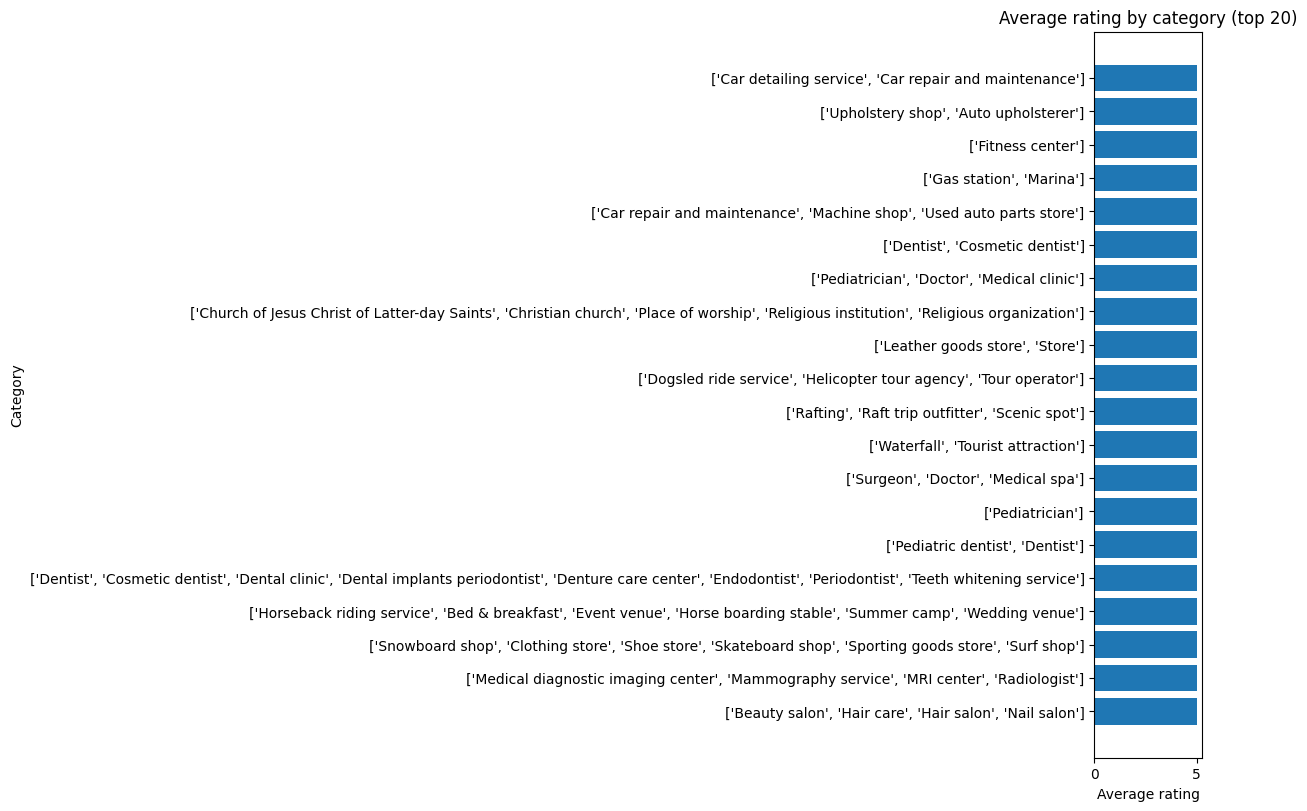

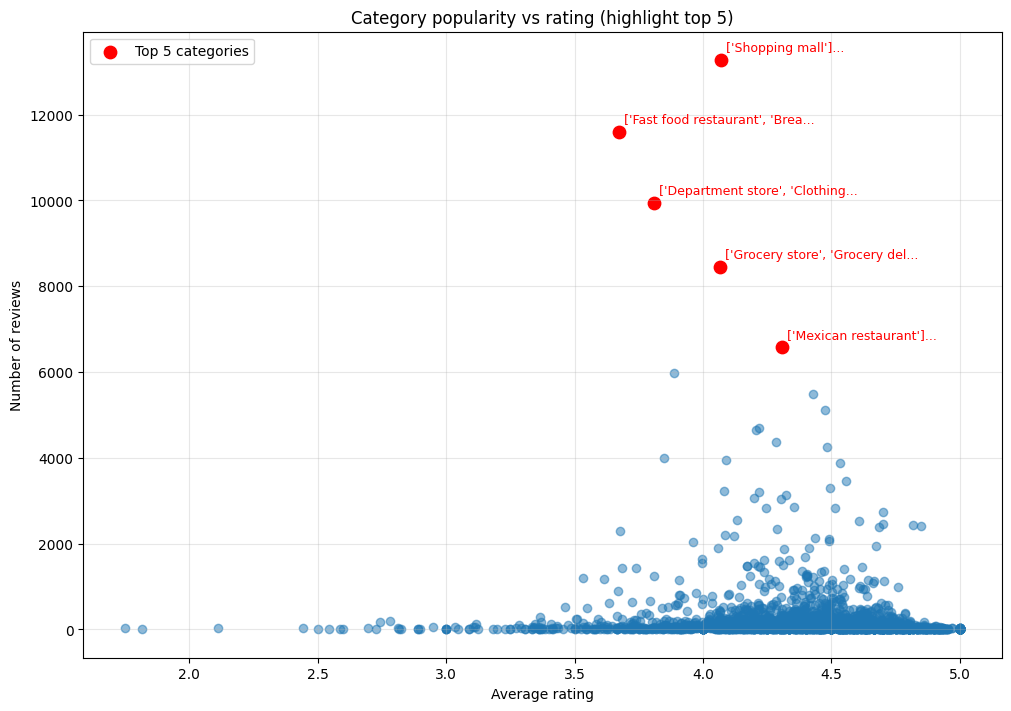

In [20]:
from pyspark.sql.functions import avg, count, col
import matplotlib.pyplot as plt

# Step 1: group by business_category -> calculate average rating and number of reviews
cat_stats_sdf = (
    joined
    .withColumn("rating", col("rating").cast("double"))   # make sure rating is numeric
    .filter(col("business_category").isNotNull())         # remove null categories
    .groupBy("business_category")
    .agg(
        avg("rating").alias("avg_rating"),
        count("*").alias("n_reviews")
    )
    .orderBy(col("avg_rating").desc())
)

# Step 2: convert to pandas for plotting
cat_stats_df = cat_stats_sdf.toPandas()

# Step 3: plot top-20 categories by average rating
topN = 20
top_df = cat_stats_df.head(topN).sort_values("avg_rating")

plt.figure(figsize=(12, 8), constrained_layout=True)
plt.barh(top_df["business_category"], top_df["avg_rating"])
plt.xlabel("Average rating")
plt.ylabel("Category")
plt.title(f"Average rating by category (top {topN})")
plt.show()

# Step 4: scatter plot average rating vs number of reviews
plt.figure(figsize=(10, 7), constrained_layout=True)
plt.scatter(cat_stats_df["avg_rating"], cat_stats_df["n_reviews"], alpha=0.5)

# >>> Added code here to highlight top 5 categories by number of reviews <<<
top5 = cat_stats_df.nlargest(5, "n_reviews")

# mark them in red
plt.scatter(top5["avg_rating"], top5["n_reviews"], color="red", s=80, label="Top 5 categories")

# add text labels for the top 5
for i, row in top5.iterrows():
    plt.text(row["avg_rating"]+0.02, row["n_reviews"]+200,   # offset for readability
             str(row["business_category"])[:30] + "...",     # truncate long names
             fontsize=9, color="red")

plt.xlabel("Average rating")
plt.ylabel("Number of reviews")
plt.title("Category popularity vs rating (highlight top 5)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


Top 30 single words in LOW ratings:
get: 2969
time: 2526
good: 2465
like: 2452
one: 2122
back: 2037
never: 1902
order: 1814
even: 1703
got: 1701
customer: 1470
people: 1464
didn: 1377
staff: 1280
bad: 1213
rude: 1190
minutes: 1180
went: 1176
said: 1094
told: 1088
way: 1080
going: 1055
ordered: 1036
really: 1014
better: 994
great: 974
wait: 926
ever: 903
took: 874
much: 870


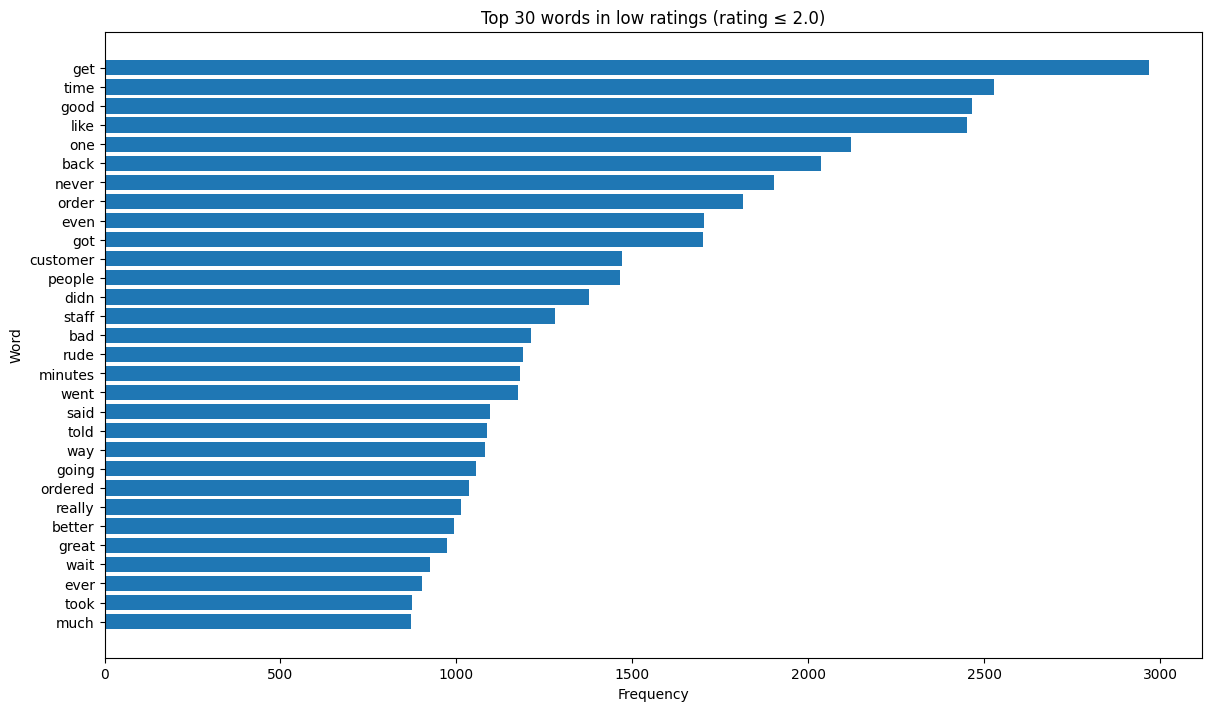

In [23]:
# Q1.7.2 — Focus on low ratings and find common single words (unigrams)
from pyspark.sql.functions import col, explode, length, lower, regexp_replace
from pyspark.ml.feature import RegexTokenizer, StopWordsRemover
import matplotlib.pyplot as plt

LOW_THRESH = 2.0  # threshold for "low rating"

# Step 1: filter low-rating reviews and clean text a bit
low_sdf = (
    joined
    .withColumn("rating", col("rating").cast("double"))
    .filter(col("rating") <= LOW_THRESH)
    .select("business_category", "name", "text")
    .dropna(subset=["business_category", "text"])
    .filter(col("text") != "no review")
    # normalize: keep only letters/numbers/spaces and lowercase
    .withColumn("text", lower(regexp_replace(col("text"), r"[^a-zA-Z0-9\s]", " ")))
)

# Step 2: tokenize words
rtok = RegexTokenizer(inputCol="text", outputCol="words", pattern=r"\s+")
tok_sdf = rtok.transform(low_sdf)

# Step 3: remove stopwords
base_sw = StopWordsRemover.loadDefaultStopWords("english")
rem = StopWordsRemover(inputCol="words", outputCol="clean", stopWords=base_sw)
clean_sdf = rem.transform(tok_sdf)

# Step 4: explode single words and filter short tokens
tokens_sdf = (
    clean_sdf
    .select(explode(col("clean")).alias("token"))
    .filter(length(col("token")) >= 3)
)

# Step 5: count token frequency in Spark
word_counts_sdf = (
    tokens_sdf
    .groupBy("token")
    .count()
    .orderBy(col("count").desc())
)

# Show top 30 words
topN = 30
top_words = word_counts_sdf.limit(topN).toPandas()
print("Top 30 single words in LOW ratings:")
for _, r in top_words.iterrows():
    print(f"{r['token']}: {int(r['count'])}")

# plot bar chart of top words
plt.figure(figsize=(12, 7), constrained_layout=True)
plt.barh(top_words["token"][::-1], top_words["count"][::-1])  # reverse to show highest at top
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.title(f"Top {topN} words in low ratings (rating ≤ {LOW_THRESH})")
plt.show()


## **Answer 1.8**

We sort each reviewer’s reviews by newtime (parsed to a timestamp), then collect the business names (joined from the meta table) into a list. This preserves the chronological order of visits.

In [24]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

meta_business_sdf = spark.createDataFrame(
    meta_business_df[["gmap_id", "business_name"]]
).withColumn("gmap_id", F.col("gmap_id").cast("string"))


reviews_sdf = spark.read.option("header", True).csv("./data/review.csv")

# Align types
reviews_sdf = (reviews_sdf
    .withColumn("gmap_id", F.col("gmap_id").cast("string"))
    .withColumn("user_id", F.col("user_id").cast("string"))
)


reviews_sdf = (reviews_sdf
    .withColumn("time_ms", F.col("time").cast("double"))
    .withColumn("newtime", F.from_unixtime(F.col("time_ms")/1000).cast("timestamp"))
)

# Join to get BUSINESS name (business_name) ---
joined = reviews_sdf.join(meta_business_sdf, on="gmap_id", how="left")

# Q1.8.1: build time-ordered list of BUSINESS names per user
w = Window.partitionBy("user_id").orderBy(F.col("newtime").asc())
user_business = (joined
    .filter(F.col("business_name").isNotNull())
    .withColumn("rn", F.row_number().over(w))
    .orderBy("user_id", "rn")
    .groupBy("user_id")
    .agg(F.collect_list("business_name").alias("user_business_list"))
)

user_business.show(10, truncate=False)


+----------------------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|user_id               |user_business_list                

1.8.2. Some reviewers may review the same business multiple times. We use array_distinct to keep only the first occurrence while preserving order, then compare list sizes before/after to quantify duplicates.

In [25]:
user_business = (user_business
    .withColumn("size_before", F.size("user_business_list"))
    .withColumn("user_business_list_dedup", F.array_distinct("user_business_list"))
    .withColumn("size_after", F.size("user_business_list_dedup"))
    .withColumn("removed_duplicates", F.col("size_before") - F.col("size_after"))
)

user_business.select("user_id", "size_before", "size_after", "removed_duplicates") \
             .orderBy(F.desc("removed_duplicates")).show(20, truncate=False)


+----------------------+-----------+----------+------------------+
|user_id               |size_before|size_after|removed_duplicates|
+----------------------+-----------+----------+------------------+
|1.0188830200557922e+20|347        |262       |85                |
|1.03692833808364e+20  |291        |224       |67                |
|1.1220090844478289e+20|305        |241       |64                |
|1.1285432402677834e+20|222        |162       |60                |
|1.0132917914176386e+20|317        |258       |59                |
|1.0497390033331505e+20|244        |190       |54                |
|1.1765545804560885e+20|304        |251       |53                |
|1.1725911130736656e+20|186        |136       |50                |
|1.0653970300675011e+20|246        |199       |47                |
|1.0456469894856294e+20|165        |124       |41                |
|1.088855411959244e+20 |240        |199       |41                |
|1.1081139080654142e+20|149        |109       |40             

1.8.3 User similarity is computed from the set of businesses each user reviewed using Jaccard:

Jaccard
(𝐴,𝐵)=∣𝐴∩𝐵∣/∣𝐴∪𝐵∣∈[0,1]


In [ ]:
# Pairwise Jaccard using built-in array functions
pairs = (user_business.alias("u1")
  .join(user_business.alias("u2"), F.col("u1.user_id") < F.col("u2.user_id"))
  .select(
      F.col("u1.user_id").alias("user_a"),
      F.col("u2.user_id").alias("user_b"),
      (
        F.when(
          F.size(F.array_union("u1.user_business_list_dedup", "u2.user_business_list_dedup")) == 0,
          F.lit(0.0)
        ).otherwise(
          F.size(F.array_intersect("u1.user_business_list_dedup", "u2.user_business_list_dedup")) /
          F.size(F.array_union("u1.user_business_list_dedup", "u2.user_business_list_dedup"))
        )
      ).alias("jaccard")
  ))

# Top similar pairs
pairs.orderBy(F.desc("jaccard")).show(20, False)


# **Part 2**

## **Answer 2.1**

In [ ]:
"""
This question focuses on the total number of reviews per day to form a review
 volume time series.
Explore the review volume time series. Add any missing days with the mean value
 of the number of review per day in the whole data.
Decompose the submission review time series with addictive mode and analyses on
the results to find if there is any seasonality pattern.
"""

from pyspark.sql.functions import to_date, count
import matplotlib.pyplot as plt

# Start with spark sdf_cleaned dataframe from Q1.2.2

# Convert timestamp to date (drops the time part)
sdf_date = sdf_cleaned.withColumn("date", to_date("newtime"))

# Group by date and count the number of reviews per day
sdf_review_volume = sdf_date.groupBy("date").agg(count("*").alias("daily_reviews"))

# Sort by date
sdf_review_volume = sdf_review_volume.orderBy("date")

# Convert the current pyspark dataframe to pandas
df_review_volume = sdf_review_volume.toPandas()

# Convert "date" to a DateTime datatype
df_review_volume["date"] = pd.to_datetime(df_review_volume["date"])

# Set "date" as the index
df_review_volume.set_index("date", inplace=True)

# Calculate the mean of the daily review counts
mean_reviews = df_review_volume.mean()
median_reviews = df_review_volume.median()

print(f"Mean number of reviews per day: {mean_reviews.iloc[0]:.1f}")
print(f"Median number of reviews per day: {median_reviews.iloc[0]:.1f}")

# Create a complete date range from the min to max date in the data
full_date_range = pd.date_range(start=df_review_volume.index.min(),
                                end=df_review_volume.index.max())

# Find which dates from the full range are NOT in our original df_review_volume
# index
missing_days = full_date_range.difference(df_review_volume.index)

# Print the number of missing days
if not missing_days.empty:
    print(f"Number of days missing from the dataset: {len(missing_days)}")
    print(f"Representing {len(missing_days)*100.0/len(full_date_range):.1f}% of the dataset.")
else:
    print("No days were missing in the dataset.")

# Reindex the df_review_volume series with the complete date range
reviews_timeseries = df_review_volume.reindex(full_date_range)

# Fill missing values with the mean
reviews_timeseries.fillna(value=mean_reviews, inplace=True)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# Daily review counts original data
axes[0].plot(df_review_volume.index, df_review_volume.daily_reviews, linestyle="-")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Review Count")
axes[0].set_title("Daily Review Counts Over Time (original)")
axes[0].grid(True)

# Daily review counts with imputed values
axes[1].plot(reviews_timeseries.index, reviews_timeseries.daily_reviews,
            linestyle="-", color="green")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Review Count")
axes[1].set_title("Daily Review Counts Over Time (imputed)")
axes[1].grid(True)

plt.tight_layout()
plt.show()

**Question says to use mean, but give nthe outliers i think median would be better. Should we make this statement and use median??**

In [ ]:
"""
Decomposition of timeseries and seasonal investigation
"""
from statsmodels.tsa.seasonal import seasonal_decompose

# Additive Decomposition
add_result = seasonal_decompose(reviews_timeseries["daily_reviews"], model='additive', period=365)

# Plot the decomposition
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

#add_result.plot().suptitle('Daily Reviews Decompose', fontsize=12)
add_result.observed.plot(ax=axes[0], title=f'Observed (Period=365)')
add_result.trend.plot(ax=axes[1], title='Trend')
add_result.seasonal.plot(ax=axes[2], title='Seasonal')
add_result.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

print()
# Limit the seasonal plot to a smaller time range to reduce clutter
seasonal_subset_1 = add_result.seasonal['2010-01-01':'2012-01-01']
seasonal_subset_2 = add_result.seasonal['2014-01-01':'2016-01-01']
seasonal_subset_3 = add_result.seasonal['2018-01-01':'2020-01-01']

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=False)

seasonal_subset_1.plot(ax=axes[0], title='Seasonal (Period=365) 2010-2012')
seasonal_subset_2.plot(ax=axes[1], title='Seasonal (Period=365) 2014-2016')
seasonal_subset_3.plot(ax=axes[2], title='Seasonal (Period=365) 2018-2020')

plt.tight_layout()
plt.show()

In [ ]:

# Periods to test
periods = [7, 30, 365]

# Plot seasonal decompositions for different periods
fig, axes = plt.subplots(len(periods), 1, figsize=(12, len(periods)*4))

for i, period in enumerate(periods):
    result = seasonal_decompose(reviews_timeseries["daily_reviews"], model="additive", period=period)
    result.seasonal["2019-01-01":"2020-01-01"].plot(ax=axes[i], title=f"Period({period})")

plt.tight_layout()
plt.suptitle("Seasonal Decomposition with Different Periods", fontsize=16, y=1.02)
plt.show()

### The weekly seasonal plot shows a suggests reviews spike on Sundays and dip mid-week.
### The monthly seasonal plot doesn't have a distinct pattern. It appear to be affected by the weekly.
### The yearly seasona plot shows a strong annual cycle, with significant variation across the year. Yealy season affect is much larger then monthly or weekly (range of ~140 versus 12).
### Peaks around July–August: Suggests higher review activity or seasonal uplift during mid-year.
### Troughs around December–January: Indicates lower activity during the early-year period.

## **Answer 2.2**

In [ ]:
"""
Find the best model with different parameters on ARIMA model with lowest Mean
Absolute Error. The parameter range for p,d,q are all from [0, 1, 2].

Also, you are required to discuss with your group member on exploring the deep
learning time series forecasting methods such as LSTM and RNN. Please write down your discussion
around the necessary data wrangling and modeling steps (steps on how to achieve, not actual code).
Also please give the reference of the deep learning time series forecasting models you are using. Please
also include your discussion details and implementation in the report.
"""
!pip install "statsmodels"
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings

# Suppress all UserWarnings
warnings.filterwarnings("ignore", category=UserWarning)

In [ ]:
# Find the differencing paramter d

plt.rcParams.update({'figure.figsize':(12,12), 'figure.dpi':60})

# Original Series
fig, axes = plt.subplots(3, 2)
axes[0, 0].plot(reviews_timeseries["daily_reviews"]); axes[0, 0].set_title('Original Series')
plot_acf(reviews_timeseries["daily_reviews"], ax=axes[0, 1])

# 1st Differencing
axes[1, 0].plot(reviews_timeseries["daily_reviews"].diff()); axes[1, 0].set_title('1st Order Differencing')
plot_acf(reviews_timeseries["daily_reviews"].diff().dropna(), ax=axes[1, 1])

# 2nd Differencing
axes[2, 0].plot(reviews_timeseries["daily_reviews"].diff().diff()); axes[2, 0].set_title('2nd Order Differencing')
plot_acf(reviews_timeseries["daily_reviews"].diff().diff().dropna(), ax=axes[2, 1])
plt.tight_layout()
plt.show()

## From the plot it looks like d should be either 0 or 1.

In [ ]:
# Find the order of the AR term (p)
# PACF plot of 1st differenced series
plt.rcParams.update({'figure.figsize':(8,5), 'figure.dpi':120})

fig, axes = plt.subplots(2, 1)
axes[0].plot(reviews_timeseries["daily_reviews"]); axes[0].set_title('No Differencing')
axes[1].set(ylim=(0,5))
plot_pacf(reviews_timeseries["daily_reviews"], ax=axes[1])


plt.tight_layout()
plt.show()

## The significant spikes appear at lag 1 and possibly lag 2, which supports choosing AR order p = 2.

In [ ]:
# Find the order of the MA term (q)
fig, axes = plt.subplots(2, 1)
axes[0].plot(reviews_timeseries["daily_reviews"]); axes[0].set_title('No Differencing')
axes[1].set(ylim=(0,1.2))
plot_acf(reviews_timeseries["daily_reviews"], ax=axes[1])

plt.tight_layout()
plt.show()

In [ ]:
# This cell uses the walk-forward grid search code from the SIT742 M05B-ARIMA
# notebook, however modifies it for performance

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error

# Split into train and test sets
X = reviews_timeseries["daily_reviews"].values

# 70/30 split in test/train
size = int(len(X) * 0.70)
train, test = X[0:size], X[size:]

MAE = []
p = [0, 1, 2]
q = [0, 1, 2]
d = [0, 1, 2]

# Grid search
for pi in p:
  for qi in q:
    for di in d:
      history = [x for x in train]
      predictions = []
      # Walk-forward - extremly slow if the model is updated at every step
      for t in range(len(test)):
        # Fit the model every 100 steps or at the first step
        if t % 100 == 0 or t == 0:
          model = ARIMA(history, order=(pi, di, qi))
          model_fit = model.fit()

        output = model_fit.forecast()
        yhat = output[0]
        predictions.append(yhat)
        obs = test[t]
        history.append(obs)

      mae = mean_absolute_error(test, predictions)
      MAE.append((mae, pi, di, qi))
      print(f"Test MAE: {mae:.3f}, {pi}, {di}, {qi}")

min_mae = min(MAE)
print(f"Smallest MAE:{min_mae[0]} for ({min_mae[1]}, {min_mae[2]}, {min_mae[3]})")


In [ ]:
history = [x for x in train]
predictions = list()
best_parameter = list(min_mae[-3:])
confidence_interval = []

# Define ARIMA order
order = (best_parameter[0], best_parameter[1], best_parameter[2])
model = ARIMA(history, order=order)
model_fit = model.fit()

# Walk-forward validation
for t in range(len(test)):
    # Forecast one step ahead
    output = model_fit.get_forecast()
    yhat = output.predicted_mean
    predictions.append(yhat)

    # Update training data with new observation
    obs = test[t]
    history.append(obs)

    ci = output.conf_int(0.05)
    confidence_interval.append(ci[0])

    # Refit only if necessary (optimization)
    if t % 15 == 0:  # Refit every XX steps to balance performance
        model = ARIMA(history, order=order)
        model_fit = model.fit()

# Evaluate forecasts
mae = mean_absolute_error(test, predictions)
print(f"Walk-forward validation MAE: {mae:.3f}")

# Plot forecasts against actual outcomes and also the confidence int at 95%
plt.plot(test)
plt.plot(predictions, color='red')
plt.fill_between(list(range(len(test))),
                 np.array(confidence_interval)[:,0], np.array(confidence_interval)[:,1],
                alpha=0.1, color='b')
plt.show()

## **Answer 2.3**

In [ ]:
# Install required packages
!pip install --upgrade pymupdf

# Create data directory
!mkdir -p data

# Download the data for part 1 from the the GitHub repository
!wget -qP data https://universitiesaustralia.edu.au/wp-content/uploads/2022/08/UA_Indigenous_Strategy_Annual_Report_May-2022.pdf


In [ ]:
import pymupdf
import pandas as pd
from pathlib import Path
import re
from itertools import combinations

# Helper functions
def page_text(doc, i):
    """
    Function to return the text from a specific page as a list of strings without
     any empty strings.

    :param doc: Document opened with pymupdf
    :param i: Page index
    :returns: List of strings
    """
    return [string.strip() for string in doc[i].get_text("text").splitlines() if string.strip()]

def find_caption_index(string_lst, prefix):
    """
    Function to find the index in a list for a Figure or Table caption.

    :param string_lst: List of strings
    :param prefix: String to match.
    :returns: Index of the string in the list.
    """
    return next(i for i, string in enumerate(string_lst) if string.startswith(prefix))

def before_caption(doc, i, prefix):
    """
    Function to return a slice of the list before a caption text for a given
    page index.

    :param doc: Document opened with pymupdf
    :param i: Page index
    :param prefix: String to match.
    :returns: List of strings.
    """
    string_lst = page_text(doc, i)
    j = find_caption_index(string_lst, prefix)
    return string_lst[:j]

def after_caption(doc, i, prefix):
    """
    Function to return a slice of the list after a caption text for a given
    page index.

    :param doc: Document opened with pymupdf
    :param i: Page index
    :param prefix: String to match.
    :returns: List of strings.
    """
    string_lst = page_text(doc, i)
    j = find_caption_index(string_lst, prefix)
    return string_lst[j+1:]

def window_between(string_lst, mark_start, mark_end=None):
    """
    Return the slice of the string list from the startswith(mark_start) [exclusive]
     up to the string that startswith(mark_end)[exclusive], or end-of-list if mark_end is None.

    :param string_lst: List of strings
    :param mark_start: String to match at the start.
    :param mark_end: String to match at the end.
    :returns: List of strings
    """
    s = find_caption_index(string_lst, mark_start) + 1

    if mark_end:
        e = next(i for i, string in enumerate(string_lst[s+1:], start=s+1) if string.startswith(mark_end))
    else:
        e = len(string_lst)
    return string_lst[s:e]

# Note: pymupdf reads this document as
# Text: Bottom-Up - lines from the bottom of the page appear first
# Tables/Figures: Top-Down - Text fro mthe top of tables and figures appear first.

# Path to document to parse
pdf_path = Path("data/UA_Indigenous_Strategy_Annual_Report_May-2022.pdf")

# Path to output excel workbook
out_path = Path("UA_Indigenous_Strategy_Annual_Report_Data_.xlsx")

# Dictionary to hold DataFrames for each figure
out_fig = {}

# Dictionary to hold DataFrames for each table
out_tab = {}

# Read the report
report = pymupdf.open(pdf_path)

# Common regex patterns
num_pat  = re.compile(r"^\d{1,3}(?:,\d{3})+$")  # 22,897
pct_pat = re.compile(r'^[+-]?(?:\d{1,2}(?:\.\d{1,2})?|\.\d{1,2})%$') # 1.22%, -1.0%, .12%, 1.2%, 12%
year_pat = re.compile(r"^(19|20)\d{2}$") # 2013...2021

# Figure 1 (p.9): values then years BEFORE caption
text_lst = before_caption(report, 8, "Figure 1:")
vals = []
yrs = []
state = "vals"
for string in text_lst:
    if state == "vals": # read figure values
        if num_pat.match(string):
            vals.append(int(string.replace(",","")))
        elif vals and year_pat.match(string):
            state = "years" # finsihed reading values switch to years
            yrs.append(int(string))
    else: # read years from figure
        if year_pat.match(string):
            yrs.append(int(string))
        elif yrs:
            break

# Store DataFrame
out_fig["Figure 1"] = pd.DataFrame({"Year": yrs, "Indigenous enrolments": vals})


# Figure 2 (p.9): percentages then years AFTER caption
text_lst = after_caption(report, 8, "Figure 2:")
pcts = []
yrs = []
state = "pcts"
for string in text_lst:
    if state == "pcts": # read values as percentages
        if pct_pat.match(string):
            pcts.append(float(string.replace("%", "")))
        elif pcts and year_pat.match(string):
            state = "years" # finished reading values switch to years
            yrs.append(int(string))
    else: # read years
        if year_pat.match(string):
            yrs.append(int(string))
        elif yrs:
            break

# Store DataFrame
out_fig["Figure 2"] = pd.DataFrame({"Year": yrs, "Share (%)": pcts})


# Tabel 1 (p.12): indigenenous enrolments but course level 2008 and 2020.
text_lst = page_text(report, 11)

blk_lst = window_between(text_lst, "Source: ", mark_end="Table 1:")

# The header spans 6 lines; after that, the data appears in 5-line chunks:
# [Course level, 2008, 2020, Growth %, Annual avg growth %]
data_text = blk_lst[6:]

rows = []
chunk = []
for text in data_text:
    chunk.append(text)
    if len(chunk) == 5:
        rows.append(chunk)
        chunk = []

# Build a DataFrame and clean numeric fields ---
cols = ["Course level", "2008", "2020", "Growth since 2008 (%)",
        "Annual avg growth since 2008 (%)"]
df = pd.DataFrame(rows, columns=cols)

# Convert numbers (remove thousands separators)
for c in ["2008", "2020"]:
    df[c] = df[c].str.replace(",", "").astype(int)

# Convert numbers (remove %)
for c in ["Growth since 2008 (%)", "Annual avg growth since 2008 (%)"]:
    df[c] = df[c].str.replace("%", "").astype(float)

# Store DataFrame
out_tab["Table 1"] = df


# Figure 5 (p.13): two time-series BEFORE caption
text_lst = before_caption(report, 12, "Figure 5:")
pcts = []
yrs = []
state = "pcts"
for string in text_lst:
    if state == "pcts": # read values as percentages
        if pct_pat.match(string):
            pcts.append(float(string.replace("%", "")))
        elif pcts and year_pat.match(string):
            state = "years" # finished reading values witch to years
            yrs.append(int(string))
    else: # read years
        if year_pat.match(string):
            yrs.append(int(string))
        elif yrs:
            break
n = len(yrs)
labs = [string for string in text_lst if string in ("Indigenous", "Non-Indigenous")]

# Store DataFrame
out_fig["Figure 5"] = pd.DataFrame({
        "Year": yrs*2,
        "Group": [labs[0]]*n + [labs[1]]*n,
        "Annual growth (%)": pcts[:n] + pcts[n:]
})


# Figure 6 (p.14): two series by age (pairing solver)
text_lst = page_text(report, 13)

# Window between "Source: See Figure 5." and "Figure 6:"
blk_lst = window_between(text_lst, "Source: See Figure 5.", mark_end="Figure 6:")

ages = ["15 to 19", "20 to 24", "25 to 39", "40 to 64"]
vals = [float(text.replace("%", "")) for text in blk_lst if re.match(r"^-?\d{1,2}\.?\d?%$", text)]
groups = ["Non-Indigenous", "Indigenous"]

# We know the sum of each bar must be 100
# We also know the first value is IND 15-19.
ind = [vals[0],]
ni = [vals[1],]

target_sum_ind = 100 - ind[0]
target_sum_ni = 100 - ni[0]

# Generate all combinations of 3 numbers from the list
all_triplets = list(combinations(vals[2:], 3))

# Iterate through all pairs of triplets
for triplet_a in all_triplets:
    if sum(triplet_a) == target_sum_ind:
        remaining_numbers = [n for n in vals[2:] if n not in triplet_a]
        for triplet_b in combinations(remaining_numbers, 3):
            if sum(triplet_b) == target_sum_ni:
                break
                #triplet_a, triplet_b

ind += list(triplet_a)
ni += list(triplet_b)

ni_df  = pd.DataFrame(
    [{"Age":a,"Group":groups[0],"Share (%)":ni[i]} for i, a in enumerate(ages)]
)
ind_df  = pd.DataFrame(
    [{"Age":a,"Group":groups[1],"Share (%)":ind[i]} for i, a in enumerate(ages)]
)

# Store DataFrame
out_fig["Figure 6"] = pd.concat([ni_df, ind_df], ignore_index=True)


# Figure 7 (p.14): applications vs population by age
# numbers/labels appear BEFORE "Figure 7:"
text_lst = before_caption(report, 13, "Figure 7:")
ages = ["15 to 19", "20 to 24", "25 to 39", "40 to 64"]
pcts = [float(x.replace("%","")) for x in text_lst if re.match(r"^\d{1,2}\.\d%$", x)]
series = ["Indigenous applications", "Indigenous population"]
out_fig["Figure 7"] = pd.DataFrame({
    "Age": ages*2,
    "Series": [series[0]]*4 + [series[1]]*4,
    "Share (%)": pcts
})


# Figure 8 (p.15): gender shares by group
text_lst = page_text(report, 14)
blk_lst = window_between(text_lst, "Source: See Figure 5", mark_end="Figure 8:")

rows = []
pie_slice = {}
i = 0
while i < len(blk_lst):
    text = blk_lst[i]
    if text == "Female" and i+1 < len(blk_lst) and blk_lst[i+1].endswith("%"):
        pie_slice["Female"] = float(blk_lst[i+1].replace("%", ""))
        i += 2
        continue
    if text == "Male" and i+1 < len(blk_lst) and blk_lst[i+1].endswith("%"):
        pie_slice["Male"] = float(blk_lst[i+1].replace("%", ""))
        i += 2
        continue
    if text in ("Non-Indigenous", "Indigenous") and {"Female", "Male"} <= pie_slice.keys():
        rows += [{"Group":text,"Gender":"Female","Share (%)":pie_slice["Female"]},
                 {"Group":text,"Gender":"Male",  "Share (%)":pie_slice["Male"]}]
        pie_slice = {}
        i += 1
        continue
    i += 1

# Store DataFrame
out_fig["Figure 8"] = pd.DataFrame(rows)


# Figure 11 (p.17): two series across cohorts
text_lst = before_caption(report, 16, "Figure 11:")
pcts = []
cohorts = []
state = "pcts"
co_pat = re.compile(r"^(\d{4}) Cohort$")  # e.g., "2005 Cohort"
for string in text_lst:
    if state == "pcts": # reading values as percentages
        if pct_pat.match(string):
            pcts.append(float(string.replace("%", "")))
        elif pcts and co_pat.match(string):
            state = "co" # switch to cohort
            cohorts.append(int(co_pat.match(string).group(1)))
    else:
        m = co_pat.match(string)
        if m:
            cohorts.append(int(m.group(1)))
        elif cohorts:
            break
n = len(cohorts)
labels = ["Indigenous students", "Non-Indigenous students"]

# Store DataFrame
out_fig["Figure 11"] = pd.DataFrame({
    "Cohort Year": cohorts*2,
    "Group": [labels[0]]*n + [labels[1]]*n,
    "Nine-year completion rate (%)": pcts[:n] + pcts[n:]
})


# Figure 12 (p.18): Indigenous attrition after 4 years (cohorts 2005–2017)
text_lst = before_caption(report, 17, "Figure 12:")
pcts = [float(text.replace("%", "")) for text in text_lst if pct_pat.match(text)]
yrs  = [int(text_lst[i]) for i in range(len(text_lst)-1) if year_pat.match(text_lst[i]) and text_lst[i+1].lower() == "cohort"]

# Store DataFrame
out_fig["Figure 12"] = pd.DataFrame({
        "Cohort Year": yrs[:len(pcts)],
        "Attrition after 4 years (%)": pcts
})


# Figure 13 (p.19): Retention & Success (two panels; two groups)
text_lst = before_caption(report, 18, "Figure 13:")

def panel(sub_lst, end_marker):
    """
    """
    k = find_caption_index(sub_lst, end_marker)
    blk_lst = sub_lst[:k]

    p  = [float(text.replace("%", "")) for text in blk_lst if pct_pat.match(text)]  # expect 8
    y  = [int(text) for text in blk_lst if year_pat.match(text)][-4:]  # last 4 years
    return y, p

yrs_r, pcts_r = panel(text_lst, "Retention rates") # 2nd panel
snd_panel_lst = text_lst[text_lst.index("Retention rates")+1:]
yrs_s, pcts_s = panel(snd_panel_lst, "Success rates") # 1st panel

ret = pd.DataFrame({
    "Year": yrs_r*2,
    "Group": ["Indigenous students"]*4+["Non-Indigenous students"]*4,
    "Metric": ["Retention rate"]*8,
    "Value (%)": pcts_r
})

suc = pd.DataFrame({
    "Year": yrs_s*2,
    "Group": ["Indigenous students"]*4+["Non-Indigenous students"]*4,
    "Metric": ["Success rate"]*8,
    "Value (%)": pcts_s
})

# Store DataFrame
out_fig["Figure 13"] = pd.concat([ret, suc], ignore_index=True)


# Figure 14 (p.20): Short-term employment (Undergrad / PG coursework)
text_lst = before_caption(report, 19, "Figure 14:")
vals  = [float(text.replace("%", "")) for text in text_lst if pct_pat.match(text)]   # 8 values
pairs = [("Undergraduate", "Full-time"), ("Undergraduate", "Overall"),
         ("Postgraduate coursework", "Full-time"), ("Postgraduate coursework", "Overall")]
rows = []
i = 0
for lvl, met in pairs:
    rows += [
        {"Level":lvl, "Metric":met, "Group":"Indigenous students", "Value (%)":vals[i]},
        {"Level":lvl, "Metric":met, "Group":"Non-Indigenous students", "Value (%)":vals[i+1]}
    ]
    i += 2

# Store DataFrame
out_fig["Figure 14"] = pd.DataFrame(rows)


# Figure 15 (p.21): 2018 grads – short & medium term employment
text_lst = before_caption(report, 20, "Figure 15:")
vals  = [float(text.replace("%","")) for text in text_lst if pct_pat.match(text)]  # 8 values
rows = []
i = 0
for lvl, met in pairs:  # same order as fig 14
    rows += [
        {"Level":lvl, "Metric":met, "Group":"Indigenous students", "Value (%)":vals[i]},
        {"Level":lvl, "Metric":met, "Group":"Non-Indigenous students", "Value (%)":vals[i+1]}
    ]
    i += 2

# Store DataFrame
out_fig["Figure 15"] = pd.DataFrame(rows)


# Figure 19 (p.25): Share female by duties (6 cats × 2 groups)
text_lst = before_caption(report, 24, "Figure 19:")
vals  = [float(x.replace("%","")) for x in text_lst if pct_pat.match(x)]   # 12
cats = ["Level A", "Level B", "Level C", "Level D and above", "All academic staff", "Non-academic"]
series = ["Indigenous staff", "Non-Indigenous staff"]

# Store DataFrame
out_fig["Figure 19"] = pd.DataFrame({
    "Category": cats*2,
    "Group": [series[0]]*6 + [series[1]]*6,
    "Share female (%)": vals
})


# Figure 20 (p.26): Under 40 by duties (6 cats × 2 groups)
text_lst = before_caption(report, 25, "Figure 20:")
vals  = [float(text.replace("%","")) for text in text_lst if pct_pat.match(text)]   # 12
cats = ["Level A", "Level B", "Level C", "Level D and above", "All academic staff", "Non-academic"]
series = ["Indigenous staff", "Non-Indigenous staff"]

# Store DataFrame
out_fig["Figure 20"] = pd.DataFrame({
    "Category": cats*2,
    "Group": [series[0]]*6 + [series[1]]*6,
    "Under 40 (%)": vals
})


# Figure 21 (p.27): Duties classification (2005/2010/2021; 2 groups; 4 cats)
text_lst = page_text(report, 26)
blk_lst = window_between(text_lst, "Source: ", mark_end="Figure 21:")

# Extract values
vals_all = [float(text.replace("%","")) for text in text_lst if pct_pat.match(text)]

# Remove y-axis labels
vals = [x for x in vals_all if x not in [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]]
years = [2005, 2010, 2021]
cats  = ["Level A", "Level B", "Level C", "Level D and above"]

seq = [(y,g,c) for y in years for g in ("Indigenous", "Non-Indigenous") for c in cats]

# Store DataFrame
out_fig["Figure 21"] = pd.DataFrame(seq, columns=["Year","Group","Category"]).assign(**{"Share (%)": vals})


# Figure 22 (p.28): Academic functions (2005/2010/2021; 2 groups; 3 cats)
text_lst = before_caption(report, 27, "Figure 22:")
vals  = [float(text.replace("%","")) for text in text_lst if re.match(r"^\d{1,2}\.?\d?%$", text)]  # 18
years = [int(y) for y in ("2005","2010","2021")]
cats  = ["Teaching and research", "Research only", "Teaching only"]
seq  = [(y,g,c) for g in ("Indigenous","Non-Indigenous") for y in years for c in cats]

# Store DataFrame
out_fig["Figure 22"] = pd.DataFrame(seq, columns=["Year","Group","Function"]).assign(**{"Share (%)": vals})


# Figure 23 (p.29): Actual vs parity (4 cats × 2 series)
text_lst = page_text(report, 28)
blk_lst = window_between(text_lst, "Source: ", mark_end="Figure 23:")

vals = []
for text in blk_lst:
    if text.replace(",","").isdigit():
        vals.append(int(text.replace(",","")))
cats   = ["Teaching-only", "Research-only", "Teaching and research", "Other function"]
series = ["Indigenous staff (actual numbers)", "Population parity figure"]

# Store DataFrame
out_fig["Figure 23"] = pd.DataFrame({
    "Function": cats*2,
    "Series": [series[0]]*4 + [series[1]]*4,
    "Count": vals
})


# Figure 27 (p.32): Postgrad Enrolments & Completions (actual vs parity)
text_lst = page_text(report, 31)
blk_lst = window_between(text_lst, "award completions are ", mark_end="Figure 27:")

en_idx = blk_lst.index("Enrolment")
ac_idx = blk_lst.index("Award completions")

# numbers appear before each panel label
nums_en = [int(text.replace(",","")) for text in blk_lst[:en_idx] if text.replace(",","").isdigit()]
nums_ac = [int(text.replace(",","")) for text in blk_lst[en_idx:ac_idx] if text.replace(",","").isdigit()]
cats   = ["Postgraduate research", "Postgraduate coursework"]
series = ["Actual Indigenous students", "Population parity figure"]

en_df  = pd.DataFrame({
    "Panel":"Enrolment","Category":cats*2,
    "Series":[series[0]]*2 + [series[1]]*2, "Value": nums_en
})

ac_df  = pd.DataFrame({
    "Panel":"Award completions","Category":cats*2,
    "Series":[series[0]]*2 + [series[1]]*2, "Value": nums_ac
})

# Store DataFrame
out_fig["Figure 27"] = pd.concat([en_df, ac_df], ignore_index=True)

# ---------- Write Excel workbook ----------
with pd.ExcelWriter(out_path, engine="openpyxl") as w:
    for k, df in out_fig.items():
        df.to_excel(w, index=False, sheet_name=k.replace("Figure ","Fig")[:31])

    for j, df in out_tab.items():
        df.to_excel(w, index=False, sheet_name=j.replace("Tabel ","Tab")[:31])

print(f"Saved: {out_path}")

# Stop Spark